In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *

from matplotlib.lines import Line2D
color_list = ['#0072b2', '#d55e00', '#009e73','#f0e442',
              '#cc79a7', '#e69f00', '#56b4e9', '#000000']

# Comment determiner la fin de la phase de transition?
Une première idée est de regarder le temps de simulations des avalanches. On avait vu dans un cas précédents que le temps de simulation augmentait grandement quand les patches atteignais le centre du systeme.\
Une seconde idée est d'utiliser la corrélation. On s'attend à voir la corrélation augmenter et perdre en variation quand les patches ont totalement atteint la taille du système.

## On regarde maintenant l'évolution au cours du temps de la correlation au centre du système

## On fait un system simple que l'on connait pour voir la correlation

### For an affine function

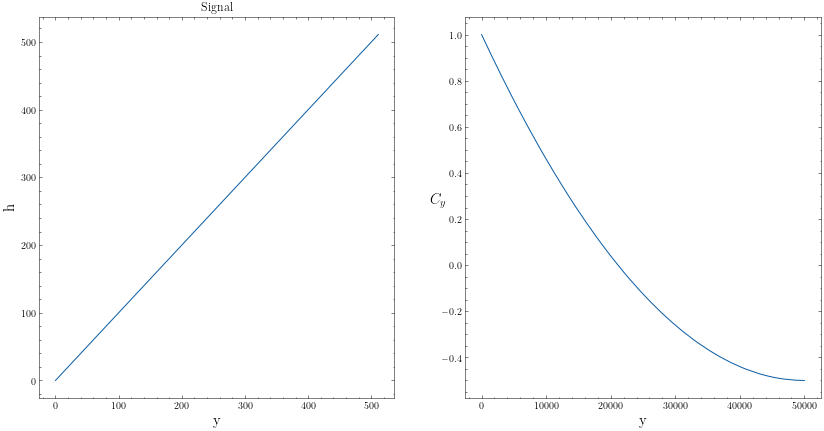

In [1]:
from tools import *

nbpoints = 500
L = 1e5
L22 = int(L/2)
mapfilepath="/home/kduplat/Documents/Data/Brut/Correlation/TestTF/Mapaf.txt"
Tffilepath="/home/kduplat/Documents/Data/Brut/Correlation/TestTF/TFaf.txt"
plt.figure(figsize=(14,7)) 

map = np.loadtxt(mapfilepath)
plt.subplot(1, 2, 1)
plt.plot(map[:512])
plt.xlabel("y", fontsize = 15)
plt.ylabel("h", fontsize = 15)
plt.title("Signal")

Tfdata = np.loadtxt(Tffilepath)
plt.subplot(1, 2, 2)

plt.plot(Tfdata[:L22])
plt.xlabel("y", fontsize = 15)
plt.ylabel(r"$C_y$", fontsize = 15, rotation = 0)  
plt.show()


Ca ne dépend ni de la valeur de la pente ni du symbole de la pente

### Periodic system

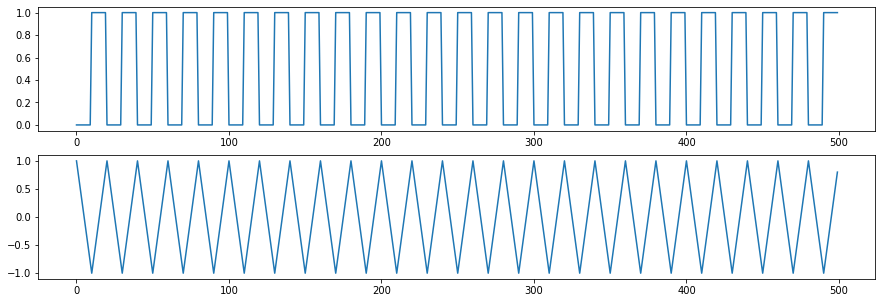

In [3]:
data = np.loadtxt('/home/kduplat/Documents/Data/Brut/Correlation/TestTF/Mapper.txt')
Tf = np.loadtxt('/home/kduplat/Documents/Data/Brut/Correlation/TestTF/tfper.txt')
plt.figure(figsize = (15,5))
plt.subplot(2,1,1)
plt.plot(data[:500])

plt.subplot(2,1,2)
plt.plot(Tf[:500,2])
plt.show()

### Fractale system

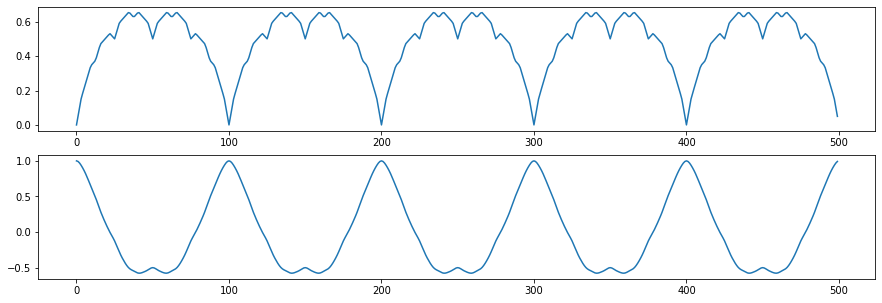

In [4]:
data = np.loadtxt('/home/kduplat/Documents/Data/Brut/Correlation/TestTF/Mapfractal.txt')
Tf = np.loadtxt('/home/kduplat/Documents/Data/Brut/Correlation/TestTF/tffractal.txt')
plt.figure(figsize = (15,5))
plt.subplot(2,1,1)
plt.plot(data[:500])

plt.subplot(2,1,2)
plt.plot(Tf[:500,2])
plt.show()

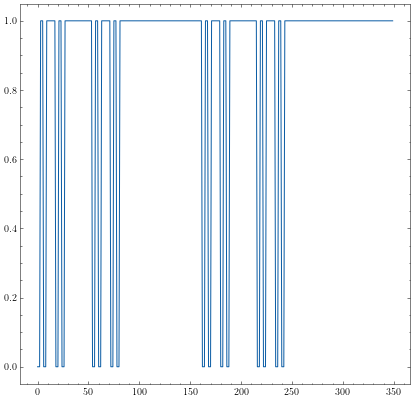

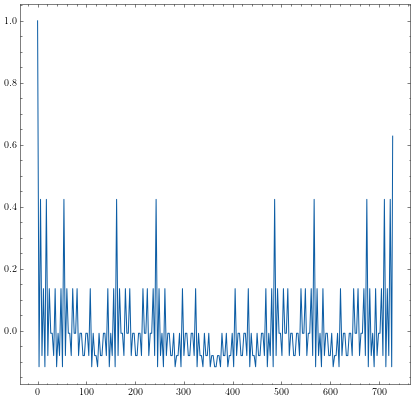

In [6]:
from tools import * 

data = np.loadtxt('/home/kduplat/Documents/Data/Brut/Correlation/TestTF/Mapfrac.txt')
Tf = np.loadtxt('/home/kduplat/Documents/Data/Brut/Correlation/TestTF/tffrac.txt')
plt.figure(figsize = (7,7))
plt.plot(data[:350])
plt.show()
plt.figure(figsize = (7,7))
plt.plot(Tf[:, 2])
plt.show()

### Telegraph process

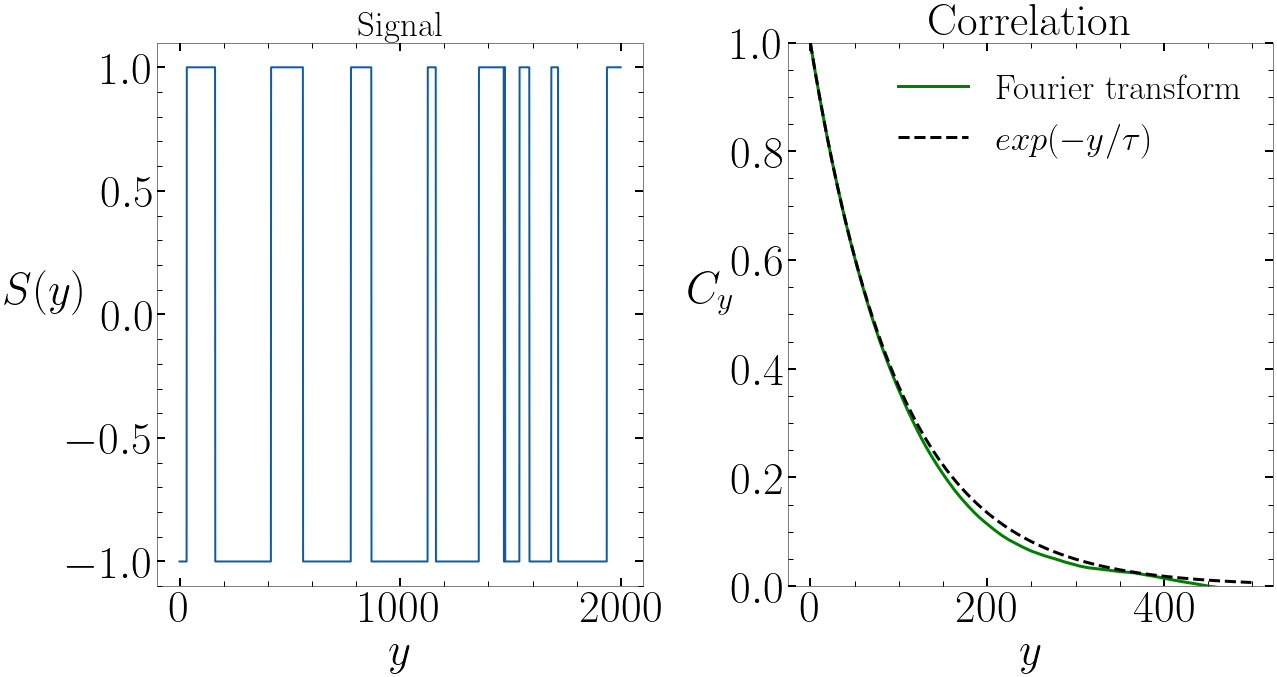

In [17]:
from tools import *
L = 1e6

filepath = "/home/kduplat/Documents/Data/Brut/Correlation/TestTF/Maptel.txt"

plt.figure(figsize=(20,10)) 
plt.subplots_adjust(wspace=0.3, hspace=0.2)
f = open(filepath, "r")

map = np.empty(int(L))
i = 0
for line in f :
    if not line.startswith('#'):
        col = line.strip().split(" ")
        map[i]= float(col[0])
        i += 1
        
plt.subplot(1, 2, 1)
plt.plot(map[:2000], linewidth = 2)
plt.xlabel(r"$y$", fontsize = 45)
plt.ylabel(r"$S(y)$", fontsize = 45, rotation = 0, labelpad = 20)
plt.tick_params(labelsize = 45,length = 8, width = 2)
plt.tick_params(labelsize = 45,length = 5, width = 1, which = 'minor')
plt.title("Signal", fontsize = 35)

L22 = int(L/2)
filepath="/home/kduplat/Documents/Data/Brut/Correlation/TestTF/tftel.txt"

corrdata = np.empty(L22)
x = np.arange(L22)

f = open(filepath, "r")
i = 0
for line in f :
    if not line.startswith('#') and not len(line.strip()) == 0:
        col = line.strip().split("  ")
        corrdata[i] = float(col[2])
        i += 1
    if i == L22:
        break 

dataexp = np.zeros(500)

for x in range(500):
    dataexp[x] = math.exp(-x/100)

plt.subplot(1, 2, 2)
plt.plot(corrdata[:500], color = "g", label = "Fourier transform", linewidth = 3)
plt.plot(dataexp[:], color = "k", linewidth = 3, linestyle = '--', label = r"$exp(-y / \tau)$")
plt.xlabel(r"$y$", fontsize = 45)
plt.ylabel(r"$C_y$", fontsize = 45, rotation = 0, labelpad = 20)       
plt.tick_params(labelsize = 45,length = 8, width = 2)
plt.tick_params(labelsize = 45,length = 5, width = 1, which = 'minor')
plt.ylim(0,1)
plt.title("Correlation", fontsize = 45)
plt.legend(fontsize = 35)



### Oscillation function

Text(0.5, 1.0, 'Correlation')

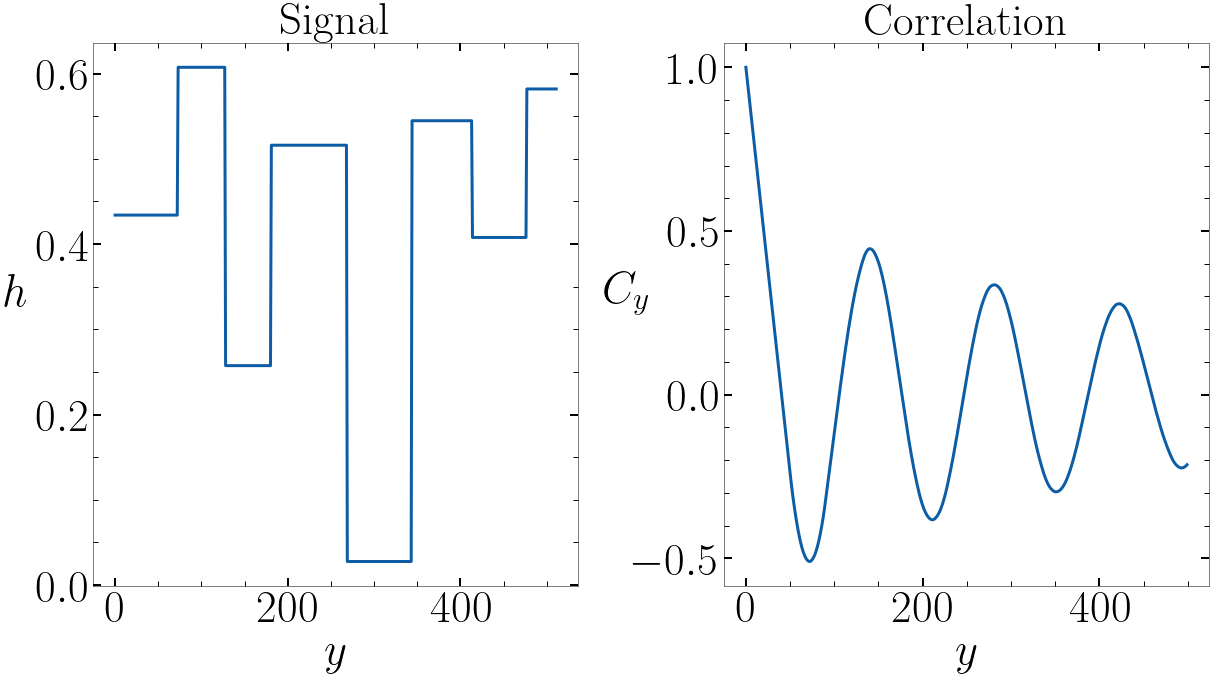

In [15]:
from tools import *

L = 1e5
filepath="/home/kduplat/Documents/Data/Brut/Correlation/TestTF/MapOs.txt"

plt.figure(figsize=(20,10)) 
plt.subplots_adjust(wspace=0.3, hspace=0.2)

map = np.empty(int(L))
i = 0
with open(filepath, "r") as f:
    for line in f :
        if not line.startswith('#'):
            col = line.strip().split(" ")
            map[i]= float(col[0])
            i += 1
        
plt.subplot(1, 2, 1)
plt.plot(map[:512], linewidth = 3)
plt.xlabel(r"$y$", fontsize = 45)
plt.ylabel(r"$h$", fontsize = 45, rotation = 0, labelpad = 20)
plt.tick_params(labelsize = 45,length = 8, width = 2)
plt.tick_params(labelsize = 45,length = 5, width = 1, which = 'minor')   
plt.title("Signal", fontsize = 45)

L22 = int(L/2)
filepath="/home/kduplat/Documents/Data/Brut/Correlation/TestTF/CorrOs.txt"

corrdata = np.empty(L22)
x = np.arange(L22)

i = 0
with open(filepath, "r") as f:
    for line in f :
        if not line.startswith('#') and not len(line.strip()) == 0:
            col = line.strip().split(" ")
            corrdata[i] = float(col[0])
            i += 1

plt.subplot(1, 2, 2)
plt.plot(corrdata[:500], linewidth = 3)
plt.xlabel(r"$y$", fontsize = 45)
plt.ylabel(r"$C_y$", fontsize = 45, rotation = 0, labelpad = 5)  
plt.tick_params(labelsize = 45,length = 8, width = 2)
plt.tick_params(labelsize = 45,length = 5, width = 1, which = 'minor')     
plt.title("Correlation", fontsize = 45)


### Pour plusieurs réalisations (s = 50, 1e5)

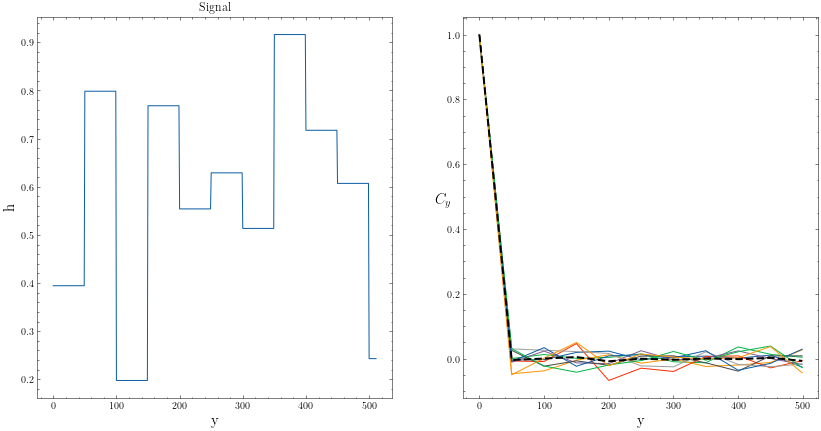

In [15]:
nbpoints = 500


L = 1e5
L22 = int(L/2)
mapfilepath="/home/kduplat/Documents/Data/Brut/Correlation/TestTF/size50rd/Map1.txt"

plt.figure(figsize=(14,7)) 
map = np.loadtxt(mapfilepath)
plt.subplot(1, 2, 1)
plt.plot(map[:512])
plt.xlabel("y", fontsize = 15)
plt.ylabel("h", fontsize = 15)
plt.title("Signal")


plt.subplot(1, 2, 2)

Tffilepath="/home/kduplat/Documents/Data/Brut/Correlation/TestTF/size50rd/tf"
nbfile = 10
Tfdata_full = np.zeros(len(map))
for i in range(nbfile):
    Tfdata = np.loadtxt(f'{Tffilepath}{i+1}.txt')
    Tfdata_full += Tfdata
    
    plt.plot(Tfdata[:nbpoints])
Tfdata_full = Tfdata_full/nbfile
plt.plot(Tfdata_full[:nbpoints], color = 'k', linestyle = '--', linewidth = 2)
plt.xlabel("y", fontsize = 15)
plt.ylabel(r"$C_y$", fontsize = 15, rotation = 0)  
plt.show()


### Multiple réalisation ( 20<s<50, 1e5)

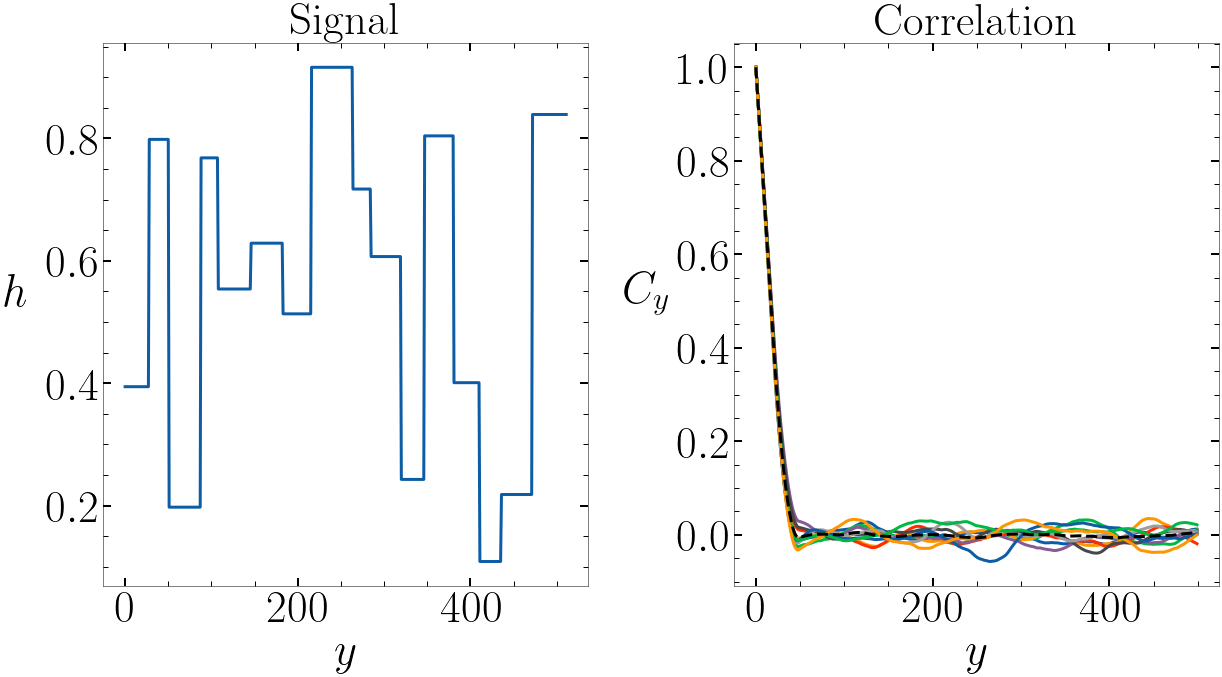

In [11]:
from tools import *
nbpoints = 500

L = 1e5
L22 = int(L/2)
mapfilepath="/home/kduplat/Documents/Data/Brut/Correlation/TestTF/size20_50rd/Map1.txt"

plt.figure(figsize=(20,10)) 
plt.subplots_adjust(wspace=0.3, hspace=0.2)

map = np.loadtxt(mapfilepath)
plt.subplot(1, 2, 1)
plt.plot(map[:512], linewidth = 3)
plt.xlabel(r"$y$", fontsize = 45)
plt.ylabel(r"$h$", fontsize = 45, rotation = 0, labelpad = 30)
plt.tick_params(labelsize = 45,length = 8, width = 2)
plt.tick_params(labelsize = 45,length = 5, width = 1, which = 'minor') 
plt.title("Signal", fontsize = 45)


plt.subplot(1, 2, 2)

Tffilepath="/home/kduplat/Documents/Data/Brut/Correlation/TestTF/size20_50rd/tf"
nbfile = 10
Tfdata_full = np.zeros(len(map))
for i in range(nbfile):
    Tfdata = np.loadtxt(f'{Tffilepath}{i+1}.txt')
    Tfdata_full += Tfdata
    
    plt.plot(Tfdata[:nbpoints], linewidth = 3)
Tfdata_full = Tfdata_full/nbfile
plt.plot(Tfdata_full[:nbpoints], color = 'k', linestyle = '--', linewidth = 3)
plt.xlabel(r"$y$", fontsize = 45)
plt.ylabel(r"$C_y$", fontsize = 45, rotation = 0, labelpad = 30)  
plt.tick_params(labelsize = 45,length = 8, width = 2)
plt.tick_params(labelsize = 45,length = 5, width = 1, which = 'minor') 
plt.title("Correlation", fontsize = 45)
plt.show()


Une taille de patch fixe fait que les variations sont affines

### Pour différentes tailles de systeme

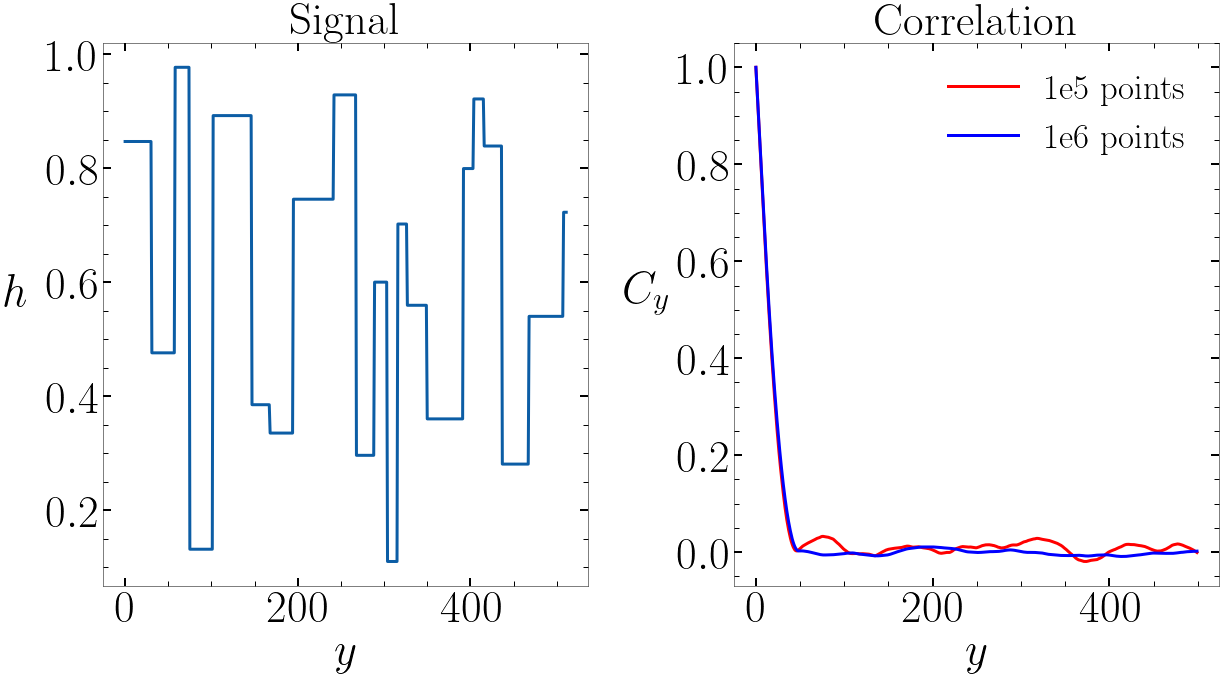

In [5]:
from tools import *
nbpoints = 500

L = 1e5
L22 = int(L/2)
mapfilepath="/home/kduplat/Documents/Data/Brut/Correlation/TestTF/Maprd1e5.txt"

plt.figure(figsize=(20,10)) 
plt.subplots_adjust(wspace=0.3, hspace=0.2)

map = np.loadtxt(mapfilepath)
plt.subplot(1, 2, 1)
plt.plot(map[:512], linewidth = 3)
plt.xlabel(r"$y$", fontsize = 45)
plt.ylabel(r"$h$", fontsize = 45, rotation = 0, labelpad = 30)
plt.tick_params(labelsize = 45,length = 8, width = 2)
plt.tick_params(labelsize = 45,length = 5, width = 1, which = 'minor') 
plt.title("Signal", fontsize = 45)


plt.subplot(1, 2, 2)

Tffilepath="/home/kduplat/Documents/Data/Brut/Correlation/TestTF/TFrd1e5.txt"
Tfdata_full = np.loadtxt(Tffilepath)
plt.plot(Tfdata_full[:nbpoints], color = 'r', linewidth = 3, label = "1e5 points")

Tffilepath="/home/kduplat/Documents/SimuQuakes/Prog/Code/testfolder/TF.txt"
Tfdata_full = np.loadtxt(Tffilepath)
plt.plot(Tfdata_full[:nbpoints], color = 'b', linewidth = 3, label = "1e6 points")

plt.xlabel(r"$y$", fontsize = 45)
plt.ylabel(r"$C_y$", fontsize = 45, rotation = 0, labelpad = 30)  
plt.tick_params(labelsize = 45,length = 8, width = 2)
plt.tick_params(labelsize = 45,length = 5, width = 1, which = 'minor') 
plt.title("Correlation", fontsize = 45)
plt.legend(fontsize = 35)
plt.show()

### We add some noise in the signal (20<s<50, 1e5, noise alternate between 2 values (noise, 0, -noise))

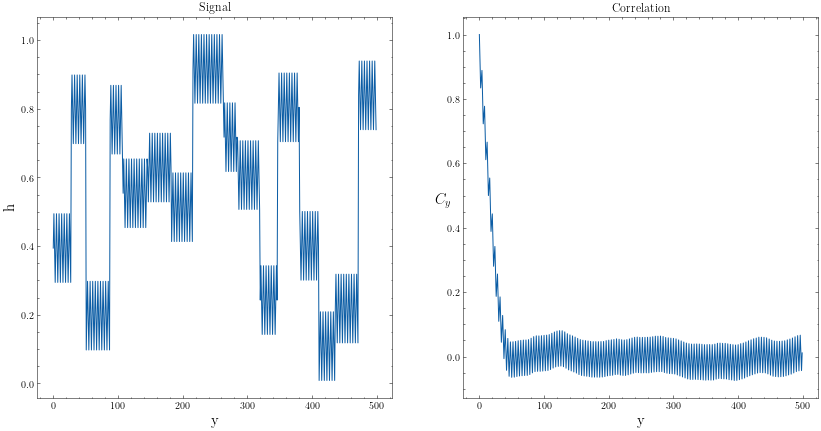

In [7]:
from tools import *

nbpoints = 500
L = 1e5
L22 = int(L/2)
mapfilepath="/home/kduplat/Documents/Data/Brut/Correlation/TestTF/Mapnoise1.txt"
Tffilepath="/home/kduplat/Documents/Data/Brut/Correlation/TestTF/TFnoise1.txt"
plt.figure(figsize=(14,7)) 

map = np.loadtxt(mapfilepath)
plt.subplot(1, 2, 1)
plt.plot(map[:500])
plt.xlabel("y", fontsize = 15)
plt.ylabel("h", fontsize = 15)
plt.title("Signal")

Tfdata = np.loadtxt(Tffilepath)
plt.subplot(1, 2, 2)

plt.plot(Tfdata[:500])
plt.xlabel("y", fontsize = 15)
plt.ylabel(r"$C_y$", fontsize = 15, rotation = 0)  
plt.title("Correlation")
plt.show()



Les oscillations dans le signal augmentent avec les oscillations dans le bruits.

### The noise is now random between 3 values (noise, 0, -noise) (s=50 , 1e5)

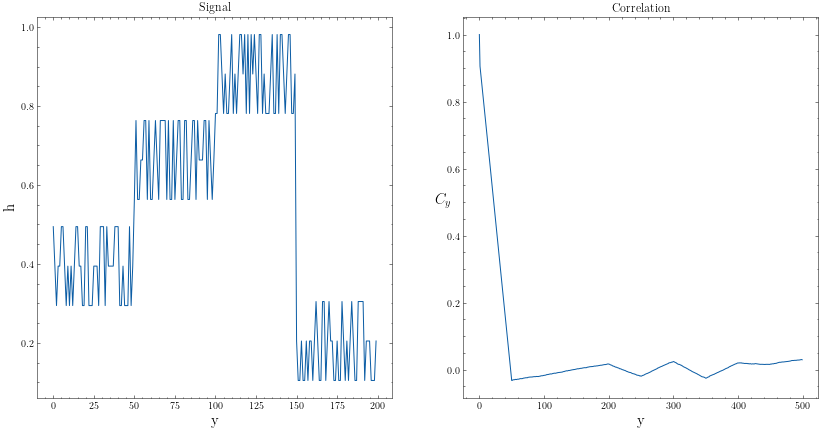

In [6]:
from tools import *

nbpoints = 500
L = 1e5
L22 = int(L/2)
mapfilepath="/home/kduplat/Documents/Data/Brut/Correlation/TestTF/Maprdnoise50.txt"
Tffilepath="/home/kduplat/Documents/Data/Brut/Correlation/TestTF/TFrdnoise50.txt"
plt.figure(figsize=(14,7)) 

map = np.loadtxt(mapfilepath)
plt.subplot(1, 2, 1)
plt.plot(map[:200])
plt.xlabel("y", fontsize = 15)
plt.ylabel("h", fontsize = 15)
plt.title("Signal")

Tfdata = np.loadtxt(Tffilepath)
plt.subplot(1, 2, 2)

plt.plot(Tfdata[:500])
plt.xlabel("y", fontsize = 15)
plt.ylabel(r"$C_y$", fontsize = 15, rotation = 0)  
plt.title("Correlation")
plt.show()


### The noise is now random between 3 values (noise, 0, -noise) (20<s<50 , 1e5)

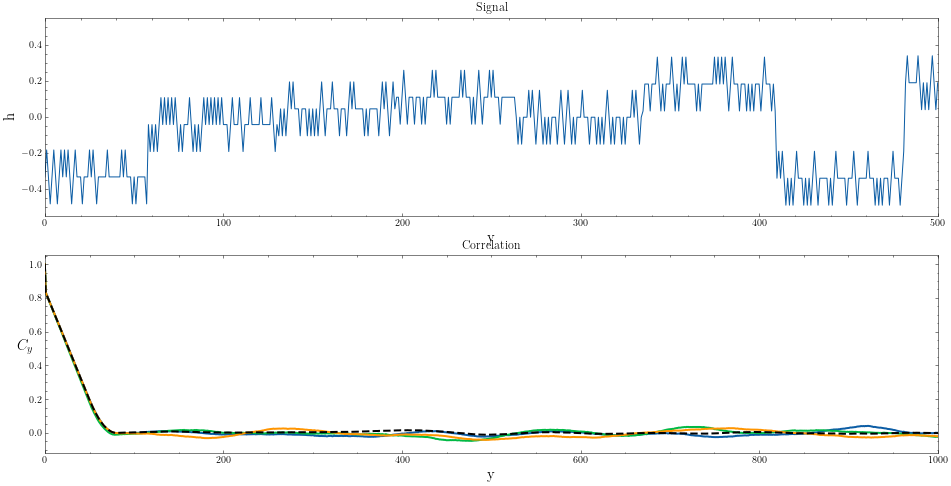

In [27]:
from tools import *


from scipy.signal import butter, lfilter, freqz
def butter_lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = lfilter(b, a, data)
    return y

def butter_lowpass(cutoff, fs, order=5):
    return butter(order, cutoff, fs=fs, btype='low', analog=False)

nbpointsTF = 1000
nbpointmap = 500

order = 1
fs = 100.0       # sample rate, Hz
cutoff = 5  # desired cutoff frequency of the filter, Hz


L = 1e5
L22 = int(L/2)
mapfilepath="/home/kduplat/Documents/SimuQuakes/Prog/Code/testfolder/Map1.txt"
Tffilepath="/home/kduplat/Documents/SimuQuakes/Prog/Code/testfolder/tf"
nbfile = 10
plt.figure(figsize=(16,8)) 

map = np.loadtxt(mapfilepath)

y = butter_lowpass_filter(map[:] - 0.5, cutoff, fs, order)

plt.subplot(2, 1, 1)
plt.plot(map[:] - 0.5, label = 'Signal')
""" plt.plot(y, linewidth = 2, label = 'Lowpass filter') """
plt.xlim((0, nbpointmap))
plt.xlabel("y", fontsize = 15)
plt.ylabel("h", fontsize = 15)
plt.title("Signal")

Tfdata_full = np.zeros(len(map))
plt.subplot(2, 1, 2)
for i in range(nbfile):
    Tfdata = np.loadtxt(f'{Tffilepath}{i+1}.txt') 
    Tfdata_full = Tfdata_full + Tfdata 
    if i < 3:
        plt.plot(Tfdata[:], linewidth = 2)

Tfdata_full = Tfdata_full/nbfile
plt.plot(Tfdata_full[:], color ='k', linewidth = 2, linestyle = '--')
plt.xlabel("y", fontsize = 15)
plt.ylabel(r"$C_y$", fontsize = 15, rotation = 0)  
plt.title("Correlation")
plt.xlim((0, nbpointsTF))
plt.show()


L = 1e5 \
\
Sans bruit: \
Légère oscillation qui varie avec la taille des patches. La décroissance est aussi fonction de la taille des patches.\
Les oscillations dépendent aussi de la plage des tailles. Plus elle est petite plus les variations sont "géométrique".\
Les oscillations semblent être d'environ 2 fois la taille des patches.\
\
Avec bruit: \
Quand on augmente le bruit il y a une décroissance rapide qui apparait pour y = 1 et la décroissance lente qui suit.\
Le bruit applani les oscillations.\
Je n'ai pas le sous pic de diminution que je vois dans la correlation des snapshots.


### On force le bruit au début et à la fin de chaque plateau (20<s<50) et si il y a un max, il est toujours suivi par un minimum


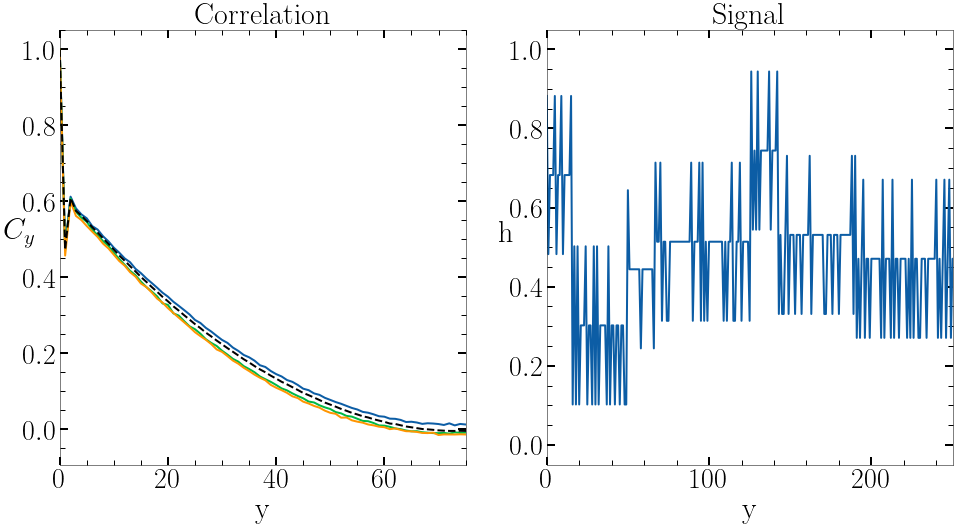

In [24]:
from tools import *


from scipy.signal import butter, lfilter, freqz
def butter_lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = lfilter(b, a, data)
    return y

def butter_lowpass(cutoff, fs, order=5):
    return butter(order, cutoff, fs=fs, btype='low', analog=False)

nbpointsTF = 1000
nbpointmap = 250

order = 1
fs = 100.0       # sample rate, Hz
cutoff = 5  # desired cutoff frequency of the filter, Hz


L = 1e5
L22 = int(L/2)
mapfilepath="/home/kduplat/Documents/SimuQuakes/Prog/Code/testfolder/Map3.txt"
Tffilepath="/home/kduplat/Documents/SimuQuakes/Prog/Code/testfolder/tf"
nbfile = 10
plt.figure(figsize=(16,8)) 

map = np.loadtxt(mapfilepath)

y = butter_lowpass_filter(map[:] - 0.5, cutoff, fs, order)
mvavg = moving_avg(map[:], 6)
plt.subplot(1, 2, 2)
plt.plot(map[:], label = 'Signal', linewidth = 2)
""" plt.plot(y, linewidth = 2, label = 'Lowpass filter') """
""" plt.plot(mvavg, linewidth = 2, label = 'Mv avg', color = 'red') """
plt.xlim((0, nbpointmap))
plt.tick_params(labelsize = 28,length = 8, width = 2)
plt.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.xlabel("y", fontsize = 30)
plt.ylabel("h", fontsize = 30, rotation = 0)
plt.title("Signal", fontsize = 30)

Tfdata_full = np.zeros(len(map))
plt.subplot(1, 2, 1)
for i in range(nbfile):
    Tfdata = np.loadtxt(f'{Tffilepath}{i+1}.txt') 
    Tfdata_full = Tfdata_full + Tfdata 
    if i < 3:
        plt.plot(Tfdata[:], linewidth = 2)

Tfdata_full = Tfdata_full/nbfile
plt.plot(Tfdata_full[:], color ='k', linewidth = 2, linestyle = '--')
plt.xlabel("y", fontsize = 30)
plt.ylabel(r"$C_y$", fontsize = 30, rotation = 0)  
plt.tick_params(labelsize = 28,length = 8, width = 2)
plt.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.title("Correlation", fontsize = 30)
plt.xlim((0, 75))
plt.show()


Apparement c'est parce qu'il y a un toujours un maximum suivi d'un minimum qu'il y a cette décroissance rapide.

## Performance test

' map = np.loadtxt(brutfile, comments="#")\nplt.subplot(1,2,1)\nplt.plot(map[:2000])\nplt.title("Signal") '

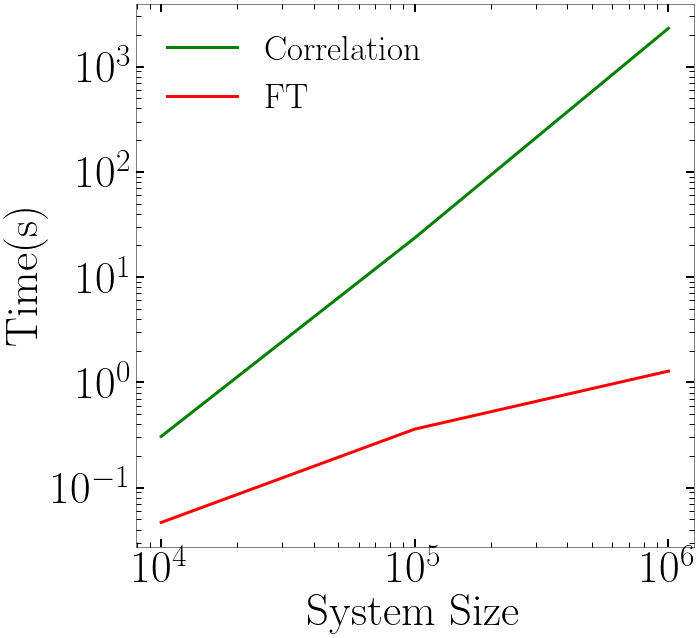

In [18]:
from tools import *

brutfile="/home/kduplat/Documents/SimuQuakes/Prog/Code/testfolder/Mapexemple.txt"

Corr = [0.3065, 23.6, 2311]
Fftw = [0.0467, 0.36, 1.28]
Size = [1e4, 1e5, 1e6]

plt.figure(figsize = (10,10))

""" plt.subplot(1,2,2) """
plt.plot(Size, Corr, label = "Correlation", color = "green", linewidth = 3)
plt.plot(Size, Fftw, label = "FT", color = "red", linewidth = 3)
plt.xlabel("System Size", fontsize = 45)
plt.ylabel("Time(s)", fontsize = 45)
plt.tick_params(labelsize = 45,length = 8, width = 2)
plt.tick_params(labelsize = 45,length = 5, width = 1, which = 'minor')
plt.yscale("log")
plt.xscale("log")
plt.legend(fontsize = 35)


""" map = np.loadtxt(brutfile, comments="#")
plt.subplot(1,2,1)
plt.plot(map[:2000])
plt.title("Signal") """

#### Correspondance test between correlation and TF

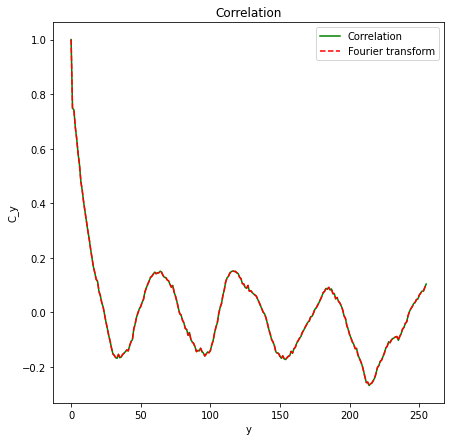

In [29]:
brutfile="/home/kduplat/Documents/Data/Brut/Test/Te16n1/tf_outputB.txt"
brutfile2="/home/kduplat/Documents/Data/Brut/Test/Te16n1/corr_outputB.txt"

L2 = int(256)

f = open(brutfile, "r")
data = np.zeros(L2)
time = 1
i = 0
for line in f :
    if not line.startswith('#') and not len(line.strip()) == 0:
        if time == 2:
            col = line.strip().split(" ")
            data[i] = float(col[2])
        i += 1
        if i == L2:
            i = 0
            time += 1
        
        
        
f = open(brutfile2, "r")
data2 = np.zeros(L2)
time = 1
i = 0
for line in f :
    if not line.startswith('#') and not len(line.strip()) == 0:
        if time == 2:
            col = line.strip().split(" ")
            data2[i] = float(col[2])
        i += 1
        if i == L2:
            i = 0
            time += 1
        
        
nbpoint = 256
plt.figure(figsize=(7,7))
plt.plot(data2[:nbpoint], color = "g", label = "Correlation")
plt.plot(data[:nbpoint], color = "r", label = "Fourier transform", linestyle = "--")
plt.xlabel("y")
plt.ylabel("C_y")
""" plt.ylim(0,1) """
plt.title("Correlation")
plt.legend()



    

La longueur de correlation semble évoluer de façon linéaire avec la longueur du systeme.\
Plus de resultat pour des systèmes plus petit son nécessaire pour s'assurer du resultat.

Pourquoi quand le système est lus petit il faut des dissipations plus grande pour voir la longueur de correlation?

## Nouvelle idée: On prend la moyenne de notre longueur de correlation. On regarde la valeur à la fin, on regarde à quelle moment on dépasse pour la première fois cetter valeur dans la longueur de correlation


### L = 64

In [1]:
from tools import *

L1 = 64
L2 = 64
iniava = 1e6
deltaava = 1e6
nbava = 1.3e9
tcorrel = [-1]
nl = 1
startmean = nbava - (nbava - iniava)*0.1

fnb = np.arange(1,16)
Tiniava = [1e5, 1e5, 1e5, 1e5, 1e5, 1e6, 1e6, 1e6, 1e6, 1e6, 1e8, 1e8, 1e8, 1e9, 1e9]
Tdeltaava = [1e5, 1e5, 1e5, 1e5, 1e5, 1e6, 1e6, 1e6, 1e6, 1e6, 1e8, 1e8, 1e8, 1e9, 1e9]
Tnbava = [6e7, 1.1e9, 1.1e9, 1.1e9, 1.1e9, 1.2e9, 1.2e9, 1.3e9, 1.3e9, 2e9, 6e9, 1e10, 5e10, 1e11, 1e11]
folderpath = [f"/data1/DATA_Duplat/Brut/OFCc/OF8n{nb}" for nb in fnb]

Tnu = np.array([0.0, 0.005, 0.01, 0.015, 0.02, 
      0.025, 0.03, 0.07, 0.1, 0.2,
      0.3, 0.4, 0.5, 0.6, 0.8])

Transiant_lim64 = np.ones(len(Tnu))

""" folderpath = "/home/kduplat/Documents/Data/Brut/OFC*gaus/OF6n16" """
""" folderpath ="/data1/DATA_Duplat/Brut/OFCc/OF8n9" """

for j, (folder, iniava, deltaava, nbava) in enumerate(zip(folderpath, Tiniava, Tdeltaava, Tnbava)):

    clentab , avgtab = corrlength(folder, iniava, deltaava, nbava, L2, 0)
    """ meanXi = meancorrfct(folderpath, tcorrel, nl, deltaava, iniava, L1,L2, nbava, clentab, startmean) """
    clenfittab, avgfittab =corrlengthfit(folder, L2, iniava, deltaava, clentab, s = 0)

    for i in range(len(clenfittab)):
        if clenfittab[i][1] > avgfittab[-1]:
            Transiant_lim64[j] = clenfittab[i][0]
            
            break


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


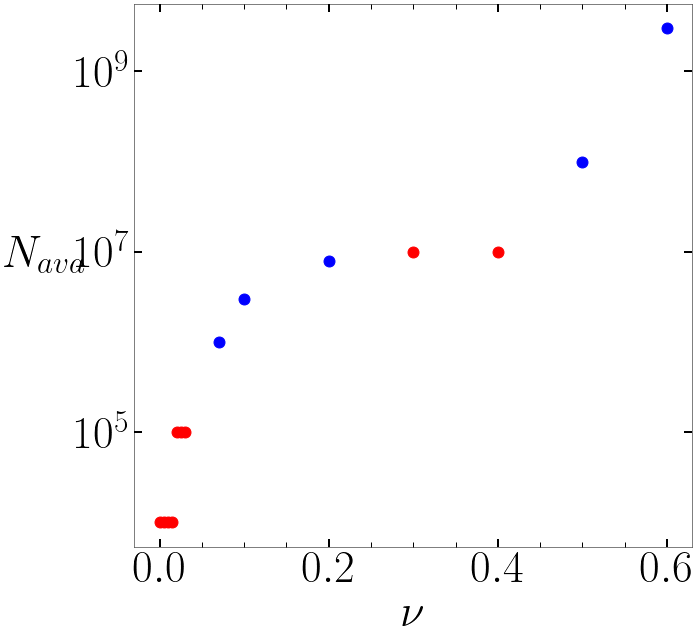

In [2]:
#correction
Transiant_lim64[0] = 1e4 
Transiant_lim64[1] = 1e4 
Transiant_lim64[2] = 1e4 
Transiant_lim64[3] = 1e4 
Transiant_lim64[4] = 1e5 
Transiant_lim64[5] = 1e5 
Transiant_lim64[6] = 1e5 
Transiant_lim64[10] = 1e7
Transiant_lim64[11] = 1e7
Transiant_lim64[-1] = 1e12 

indices_blue = [7, 8, 9, 12, 13]
indices_red = [0, 1, 2, 3, 4, 5, 6, 10, 11]

plt.figure(figsize = (10, 10))


# Scatter plot pour les indices spécifiés
plt.scatter(Tnu[indices_blue], Transiant_lim64[indices_blue], marker='o', s=120, color='b')
plt.scatter(Tnu[indices_red], Transiant_lim64[indices_red], marker='o', s=120, color='r')
plt.xlabel(r"$\nu$", fontsize = 45)
plt.ylabel(r"$N_{ava}$", fontsize = 45, rotation = 0, labelpad = 30)
plt.yscale("log")
plt.tick_params(labelsize = 45,length = 8, width = 2)
plt.tick_params(labelsize = 45,length = 5, width = 1, which = 'minor')    
plt.legend(fontsize = 35)
plt.show()

### L = 128

In [3]:
from tools import *

L1 = 128
L2 = 128
iniava = 1e6
deltaava = 1e6
nbava = 1.3e9
tcorrel = [-1]
nl = 1
startmean = nbava - (nbava - iniava)*0.1

fnb = np.arange(1,16)
Tiniava = [1e5, 1e5, 1e5, 1e5, 1e5, 1e6, 1e6, 1e6, 1e6, 1e6, 1e8, 1e8, 1e8, 1e9, 1e9]
Tdeltaava = [1e5, 1e5, 1e5, 1e5, 1e5, 1e6, 1e6, 1e6, 1e6, 1e6, 1e8, 1e8, 1e8, 1e9, 1e9]
Tnbava = [6e7, 1.1e9, 1.1e9, 1.1e9, 1.1e9, 1.2e9, 1.2e9, 1.3e9, 1.3e9, 2e9, 6e9, 1e10, 5e10, 1e11, 1e11]
folderpath = [f"/data1/DATA_Duplat/Brut/OFCc/OF9n{nb}" for nb in fnb]

Tnu = np.array([0.0, 0.005, 0.01, 0.015, 0.02, 
      0.025, 0.03, 0.07, 0.1, 0.2,
      0.3, 0.4, 0.5, 0.6, 0.8])

Transiant_lim128 = np.ones(len(Tnu))

""" folderpath = "/home/kduplat/Documents/Data/Brut/OFC*gaus/OF6n16" """
""" folderpath ="/data1/DATA_Duplat/Brut/OFCc/OF8n9" """

for j, (folder, iniava, deltaava, nbava) in enumerate(zip(folderpath, Tiniava, Tdeltaava, Tnbava)):

    clentab , avgtab = corrlength(folder, iniava, deltaava, nbava, L2, 0)
    """ meanXi = meancorrfct(folderpath, tcorrel, nl, deltaava, iniava, L1,L2, nbava, clentab, startmean) """
    clenfittab, avgfittab =corrlengthfit(folder, L2, iniava, deltaava, clentab, s = 0)

    for i in range(len(clenfittab)):
        if clenfittab[i][1] > avgfittab[-1]:
            Transiant_lim128[j] = clenfittab[i][0]
            
            break


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


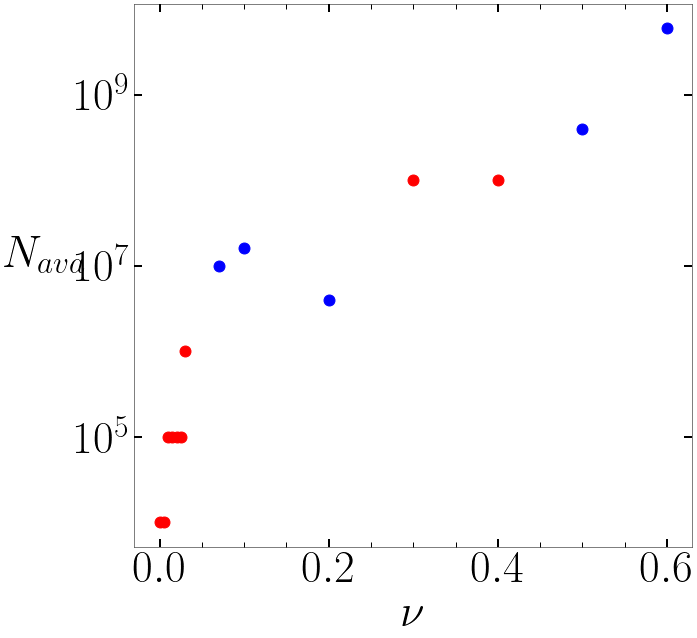

In [4]:
#correction
Transiant_lim128[0] = 1e4 
Transiant_lim128[1] = 1e4 
Transiant_lim128[2] = 1e5 
Transiant_lim128[3] = 1e5 
Transiant_lim128[4] = 1e5 
Transiant_lim128[5] = 1e5 
Transiant_lim128[6] = 1e6 
Transiant_lim128[10] = 1e8
Transiant_lim128[11] = 1e8
Transiant_lim128[-1] = 1e12 

Transiant_lim_good_data = Tnu
plt.figure(figsize = (10, 10))
indices_blue = [7, 8, 9, 12, 13]
indices_red = [0, 1, 2, 3, 4, 5, 6, 10, 11]

# Scatter plot pour les indices spécifiés
plt.scatter(Tnu[indices_blue], Transiant_lim128[indices_blue], marker='o', s=120, color='b')
plt.scatter(Tnu[indices_red], Transiant_lim128[indices_red], marker='o', s=120, color='r')

plt.xlabel(r"$\nu$", fontsize = 45)
plt.ylabel(r"$N_{ava}$", fontsize = 45, rotation = 0, labelpad = 30)
plt.yscale("log")
plt.tick_params(labelsize = 45,length = 8, width = 2)
plt.tick_params(labelsize = 45,length = 5, width = 1, which = 'minor')    
plt.legend(fontsize = 35)
plt.show()

### L = 350

In [5]:
from tools import *

L1 = 350
L2 = 350
iniava = 1e6
deltaava = 1e6
nbava = 1.3e9
tcorrel = [-1]
nl = 1
startmean = nbava - (nbava - iniava)*0.1

fnb = np.arange(2,16)
Tiniava = [1e5, 1e5, 1e5, 1e5, 1e6, 1e6, 1e6, 1e6, 1e6, 1e8, 1e8, 1e8, 1e9, 1e9]
Tdeltaava = [1e5, 1e5, 1e5, 1e5, 1e6, 1e6, 1e6, 1e6, 1e6, 1e8, 1e8, 1e8, 1e9, 1e9]
Tnbava = [1.6e8, 1.8e8, 2.2e8, 2.9e8, 4.7e8, 5.5e8, 9.5e8, 2.2e9, 4e9, 7e9, 1e10, 5e10, 1e11, 1e11]
folderpath = [f"/data1/DATA_Duplat/Brut/OFCc/OF10n{nb}" for nb in fnb]

Tnu = np.array([0.0, 0.005, 0.01, 0.015, 0.02, 
      0.025, 0.03, 0.07, 0.1, 0.2,
      0.3, 0.4, 0.5, 0.6, 0.8])

Transiant_lim = np.ones(len(fnb))

""" folderpath = "/home/kduplat/Documents/Data/Brut/OFC*gaus/OF6n16" """
""" folderpath ="/data1/DATA_Duplat/Brut/OFCc/OF8n9" """

for j, (folder, iniava, deltaava, nbava) in enumerate(zip(folderpath, Tiniava, Tdeltaava, Tnbava)):
    
    clentab , avgtab = corrlength(folder, iniava, deltaava, nbava, L2, 0)
    """ meanXi = meancorrfct(folderpath, tcorrel, nl, deltaava, iniava, L1,L2, nbava, clentab, startmean) """
    clenfittab, avgfittab =corrlengthfit(folder, L2, iniava, deltaava, clentab, s = 0)

    avgfittab=avgfittab[avgfittab[:] != 0]
    
    c = 0
    for i in range(len(clenfittab)):
        if clenfittab[i][1] > avgfittab[-1]:
            c += 1
        
            if c == 3:
                Transiant_lim[j] = clenfittab[i][0]
                break

print(Transiant_lim)

/home/kduplat/Documents/Data/Pscript/tools.py:84: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)
/home/kduplat/Documents/Data/Pscript/tools.py:84: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-b * x)


[1.00e+00 1.00e+00 1.36e+07 1.13e+07 1.50e+07 1.70e+07 4.30e+07 5.10e+07
 9.30e+07 8.00e+08 1.40e+09 1.86e+10 1.00e+00 1.00e+00]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[1.00e+05 1.00e+07 1.00e+07 1.36e+07 1.13e+07 1.50e+07 1.70e+07 4.30e+07
 5.10e+07 9.30e+07 8.00e+08 1.40e+09 1.86e+10 1.00e+00 1.00e+00]


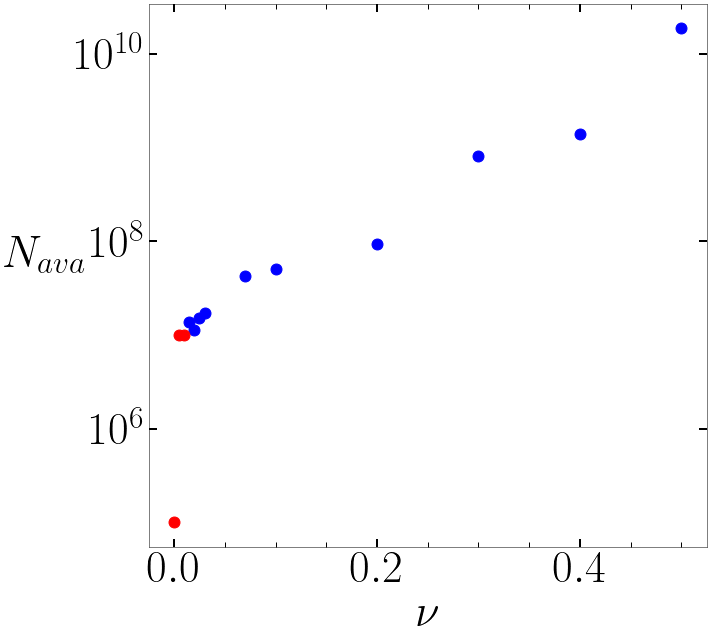

In [6]:
#correction
Transiant_lim_corr = np.insert(Transiant_lim,0, 1e5)
Transiant_lim_corr[1] = 1e7
Transiant_lim_corr[2] = 1e7
# Transiant_lim[3] = 1e7 
# Transiant_lim[4] = 1e7 
# Transiant_lim[5] = 1e8 
# Transiant_lim[6] = 1e8 

# Transiant_lim[-1] = 1e12 

print(Transiant_lim_corr)
indices_blue = [ 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
indices_red = [0, 1, 2]

plt.figure(figsize = (10, 10))
# Scatter plot pour les indices spécifiés
plt.scatter(Tnu[indices_blue], Transiant_lim_corr[indices_blue], marker='o', s=120, color='b')
plt.scatter(Tnu[indices_red], Transiant_lim_corr[indices_red], marker='o', s=120, color='r')

plt.xlabel(r"$\nu$", fontsize = 45)
plt.ylabel(r"$N_{ava}$", fontsize = 45, rotation = 0, labelpad = 30)
plt.yscale("log")
plt.tick_params(labelsize = 45,length = 8, width = 2)
plt.tick_params(labelsize = 45,length = 5, width = 1, which = 'minor')    
plt.legend(fontsize = 35)
plt.show()

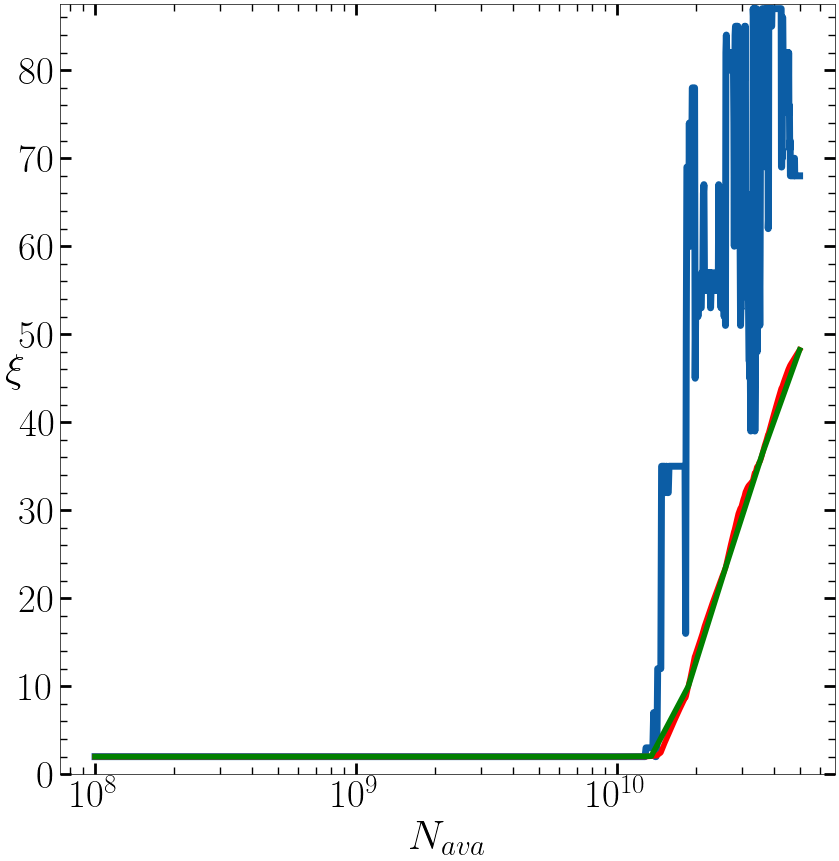

/tmp/ipykernel_1508469/922943064.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('YlOrBr')


<Figure size 700x700 with 0 Axes>

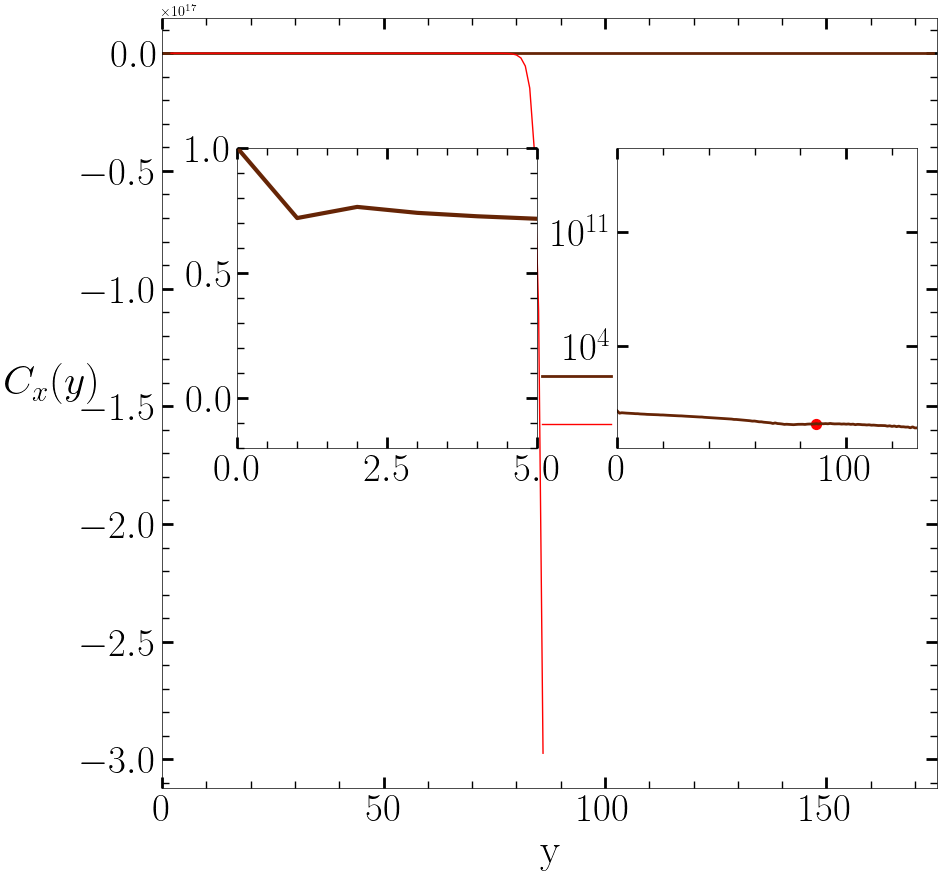

IndexError: list index out of range

In [8]:
L1 = 350
L2 = 350
iniava = 1e8
deltaava = 1e8
nbava = 5e10
tcorrel = [-1]
nl = 1
startmean =nbava - (nbava - iniava)*0.1

folderpath = "/data1/DATA_Duplat/Brut/OFCc/OF10n13"
clentab , avgtab = corrlength(folderpath, iniava, deltaava, nbava, L2, 0)
meanXi = meancorrfct(folderpath, tcorrel, nl, deltaava, iniava, L1,L2, nbava, clentab, startmean)
clenfittab, avgfittab =corrlengthfit(folderpath, L2, iniava, deltaava, clentab)
print(avgfittab[-1])

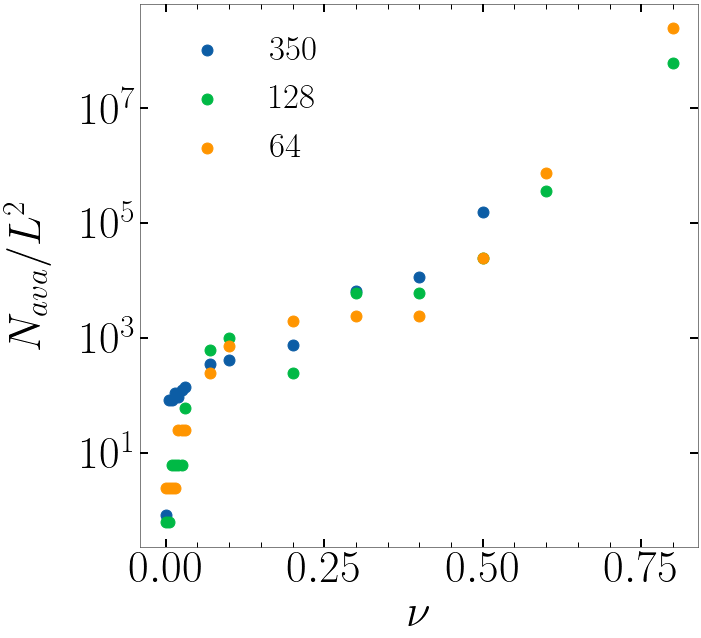

In [13]:
plt.figure(figsize = (10, 10))
# Scatter plot pour les indices spécifiés
plt.scatter(Tnu[Transiant_lim_corr != 1], Transiant_lim_corr[Transiant_lim_corr != 1]/ (350*350), marker='o', s=120, label = 350)
plt.scatter(Tnu[Transiant_lim128 != 1], Transiant_lim128[Transiant_lim128 != 1]/ (128*128), marker='o', s=120, label = 128)
plt.scatter(Tnu[Transiant_lim64 != 1], Transiant_lim64[Transiant_lim64 != 1]/( 64*64), marker='o', s=120, label = 64)

plt.xlabel(r"$\nu$", fontsize = 45)
plt.ylabel(r"$N_{ava}/L^2$", fontsize = 45, labelpad = 30)
plt.yscale("log")
plt.tick_params(labelsize = 45,length = 8, width = 2)
plt.tick_params(labelsize = 45,length = 5, width = 1, which = 'minor')    
plt.legend(fontsize = 35)
plt.show()

/home/oramos/.local/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


37720.42493416999
536697.6945540474
1422830.457214352
1698824.6726480671
1526711.3714965624
1797559.391705343
5122099.68968615
23186920.52744623
31217460.557369363
24541859.312373344
331665679.2269814
457963197.6854328
3659942871.6399646


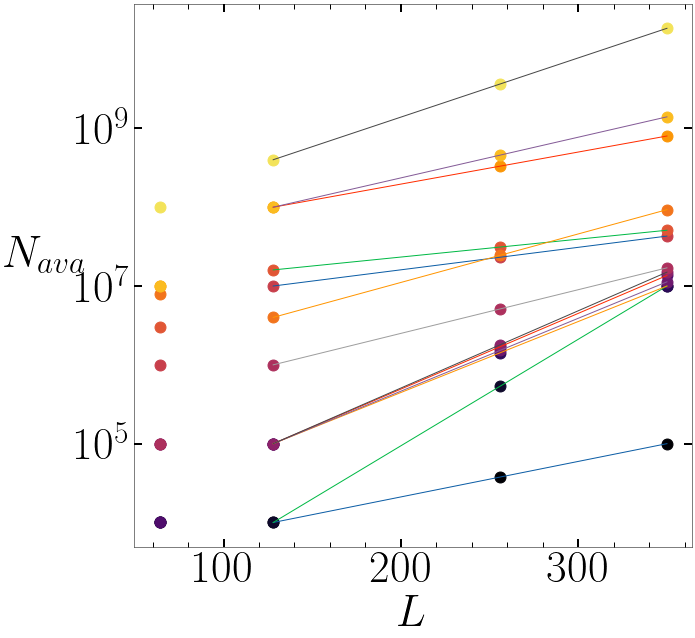

In [8]:
NCURVES = len(Tnu) - 2
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(len(Tnu) -2)]

plt.figure(figsize = (10, 10))

for j in range(len(Tnu) - 2):
    plt.scatter(350, Transiant_lim_corr[j], marker='o', s=120, color = colors[j], label = Tnu[j])
    plt.scatter(128, Transiant_lim128[j], marker='o', s=120, color = colors[j])
    plt.scatter(64, Transiant_lim64[j], marker='o', s=120, color = colors[j])
    
    # a, b = np.polyfit([128,350], [Transiant_lim128[j], Transiant_lim_corr[j]], 1)
    # Nava_256 = b + 256 * a
    
    
    popt, _ = curve_fit(expfct, np.array([128,350]), np.array([Transiant_lim128[j], Transiant_lim_corr[j]]), p0 = [1, -0.02], maxfev =100000)
    a,b = popt
    bins = np.array([128, 256, 350])
    yfit = expfct(bins, *popt)
    plt.scatter(256,yfit[1], marker = 'o' , s=120, color = colors[j])
    plt.plot([128, 256, 350], yfit, '-')
    
    print(yfit[1]) 



plt.xlabel(r"$L$", fontsize = 45)
plt.ylabel(r"$N_{ava}$", fontsize = 45, rotation = 0, labelpad = 30)
plt.yscale("log")
plt.tick_params(labelsize = 45,length = 8, width = 2)
plt.tick_params(labelsize = 45,length = 5, width = 1, which = 'minor')    
plt.show()

In [9]:
diff_64_128 = Transiant_lim128[5:-1]/Transiant_lim64[5:-1]
diff_128_350 = Transiant_lim_corr[5:-2]/Transiant_lim128[5:-2]

mean_64_128 = np.mean(diff_64_128)
mean_128_350 = np.mean(diff_128_350)

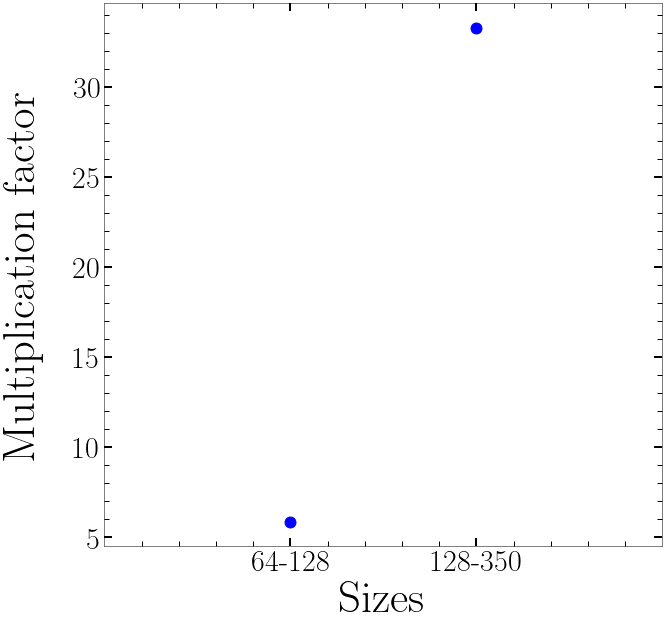

In [10]:
import matplotlib.pyplot as plt

# Définir les bins pour l'axe x
bins_x = ['64-128', '128-350']

# Définir les valeurs pour l'axe y
values_y = [mean_64_128, mean_128_350]

# Créer les positions des bins pour l'axe x (simplement utiliser les indices des bins)
x_positions = range(len(bins_x))

# Créer le graphique
plt.figure(figsize=(10, 10))

# Ajouter les points sur le graphique
plt.scatter(x_positions, values_y, color='blue', s = 120, )

# Ajouter les étiquettes des axes
plt.xticks(x_positions, bins_x)
plt.xlim(-1, 2)
plt.ylabel('Multiplication factor', fontsize = 45, labelpad = 30)
plt.xlabel('Sizes', fontsize = 45)
plt.tick_params(labelsize = 30,length = 8, width = 2)
plt.tick_params(labelsize = 30,length = 5, width = 1, which = 'minor')   

plt.show()


# Correlation length as function of the distance to the boundary

In [ ]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/PDF/PD1n{}/".format(nb) for nb in range(9,15)]
Tiniava = [read_parameters(folder)[15][0] for folder in Tfolderpath]
Tdeltaava = [read_parameters(folder)[15][1] for folder in Tfolderpath]
Tnbava = [999900000, 999900000, 9999000000, 49999000000, 499900000000, 998000000000]
Tnu = [read_parameters(folder)[2] for folder in Tfolderpath]
# Tnbava = [999900000, 998000000000]
    
# folder = "/data1/DATA_Duplat/Brut/PDF/PD1n14/"
params = read_parameters(Tfolderpath[0])
L1 = params[0]
L2 = params[1]
nbposition = 8
positions = np.array([31,63,95,127, 159, 191, 223, 255])
Txi = np.zeros((len(Tfolderpath), nbposition))
for i, (folder, iniava, deltaava, nbava) in enumerate(zip(Tfolderpath, Tiniava, Tdeltaava, Tnbava)):
    print(Tnu[i])
    for j in range(nbposition):
        print(positions[j])
        clen, avg = corrlength(folder, iniava, deltaava, nbava, L2, numcol = j,  switch_plot = 1)
        startmean = nbava - (nbava - iniava)*0.1
        meanXi = meancorrfct(folder,  deltaava, iniava, L1, L2, nbava, clen, startmean, tcorrel = [-1], numcol = j, xmin_fit = 5, switch_plot = 1)
        Txi[i,j] = meanXi


In [27]:
np.savez("Data.npz", 
         Tnu=Tnu, 
         positions = positions,
         Txi = Txi)


In [28]:
data = np.load("Data.npz", allow_pickle=True)

Tnu = data["Tnu"]
positions = data["positions"]
Txi = data["Txi"]

/tmp/ipykernel_1759348/385879428.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]


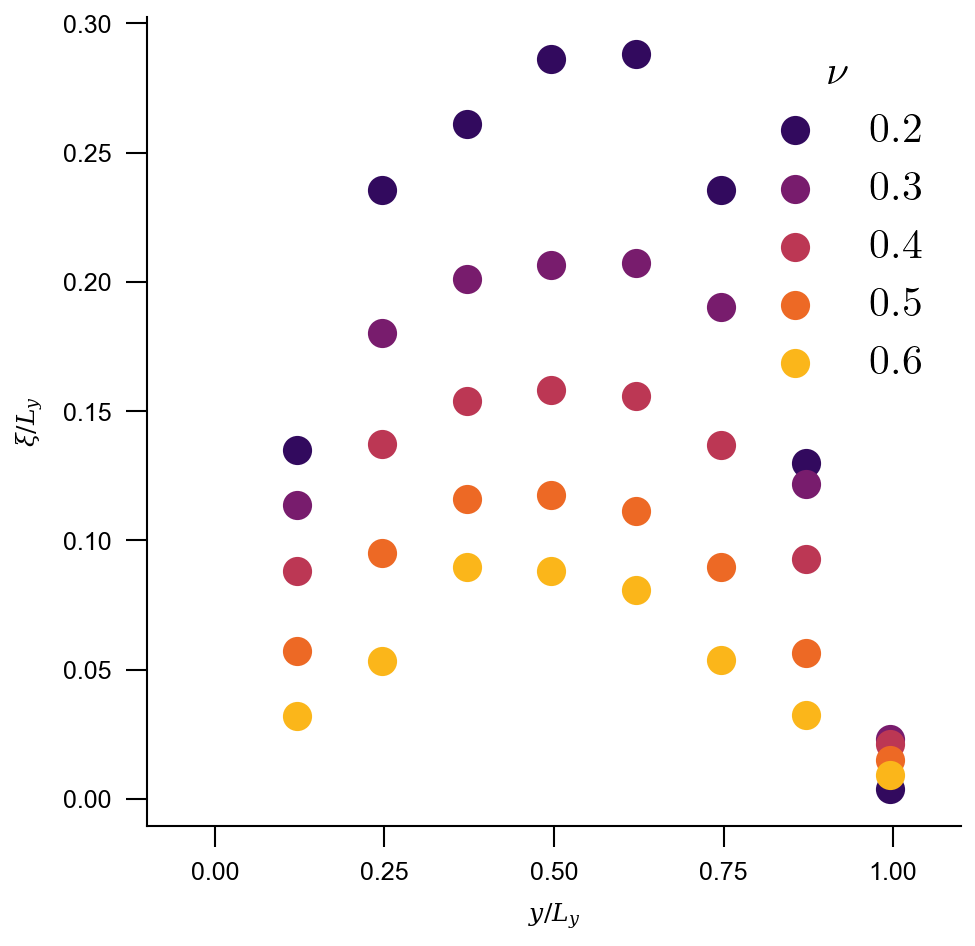

In [29]:
NCURVES = len(Tnu)
colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, ax = plt.subplots(figsize = (3.5 ,3.5))
    for i, xi in enumerate(Txi):
        if i>0:
            ax.scatter(positions/L2, xi/L2, color = colors[i], label = Tnu[i])
    ax.set_xlabel(r"$y/L_y$")
    ax.set_ylabel(r"$\xi/L_y$")

# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlim(-0.1, 1.1)
ax.legend(title = r"$\nu$")
fig.show()

/tmp/ipykernel_1759348/1542562692.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]


/home/kduplat/Documents/py38/lib/python3.8/site-packages/sciplotlib/stylesheets/nature-reviews.mplstyle
-0.39679130932847534 0.3211248585318198
-0.4241960366123259 0.3296216216091995


/tmp/ipykernel_1759348/1542562692.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(nu, Txi[i, c]/pos[j], c = colors[j], label = "y = {}\nb = {}".format(positions[c], np.round(-popt[1], 2)))
/tmp/ipykernel_1759348/1542562692.py:28: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(nu, Txi[i, c]/pos[j], c = colors[j]


-0.45668431945507376 0.3232133427378123
-0.305171625551634 0.21318757806545802


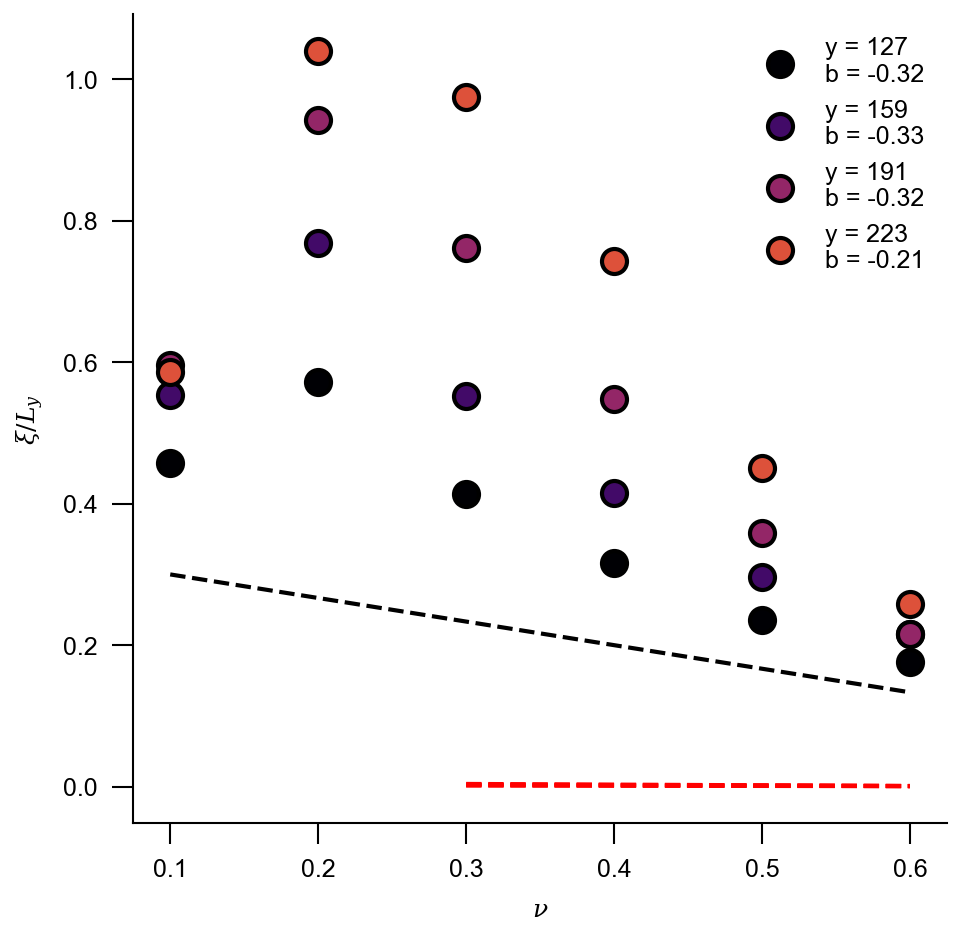

In [26]:
Tnu = [read_parameters(folder)[2] for folder in Tfolderpath]
color_list = ['#000000', '#e69f00', '#56b4e9', '#009e73',
              '#f0e442', '#0072b2', '#d55e00', '#cc79a7']

y = (1-np.array(Tnu))/3
col = [3,4,5,6,7]
pos = [128, 96, 64, 32, 1]
NCURVES = len(col)
colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    print(spstyle.get_style('nature-reviews'))
    plt.rcParams['font.family'] = 'Arial' 
    fig, ax = plt.subplots(figsize = (3.5 ,3.5))
    for j, c in enumerate(col[:-1]):
        
        xfit = np.array(Tnu[2:]) 
        # popt, pcov = curve_fit(expfct2, xfit, np.log10(Txi[2:, c]/L2), p0 = [0.5, 3], maxfev = 1000)
        # yfit = 10**(expfct2(xfit, *popt))
        
        popt, pcov = curve_fit(linlaw, xfit, Txi[2:, c]/L2, p0 = [0.5, 3], maxfev = 1000)
        yfit = linlaw(xfit, *popt)
        print(popt[0], popt[1])
        for i, nu in enumerate(Tnu):
            if i ==0:
                ax.scatter(nu, Txi[i, c]/pos[j], c = colors[j], label = "y = {}\nb = {}".format(positions[c], np.round(-popt[1], 2)))
            else:
                ax.scatter(nu, Txi[i, c]/pos[j], c = colors[j]
                           )
        ax.plot(xfit, yfit/pos[j], c  ='r', ls = '--')
    
    fit = (1-np.array(Tnu))/3
    ax.plot(Tnu, fit, c = 'k', ls = '--')
       
    ax.set_xlabel(r"$\nu$")
    ax.set_ylabel(r"$\xi/L_y$")

    # ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.legend(bbox_to_anchor = [1,1])
    fig.show()

#  Etude plus approfondie. Longueur de correlation en utilisant l'air sous la courbe REFbc

## Fonction de correlation 1 simu

In [26]:
folder = "/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp3n7"
params = read_parameters(folder)
L1 = params[0]
L2 = params[1]

data = np.loadtxt("{}/tf_temp_outputB.txt".format(folder), comments = '#')
print(np.shape(data))

NCURVES = len(data)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

(128, 256)


/tmp/ipykernel_3730087/3512847652.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


/tmp/ipykernel_3730087/2568065996.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


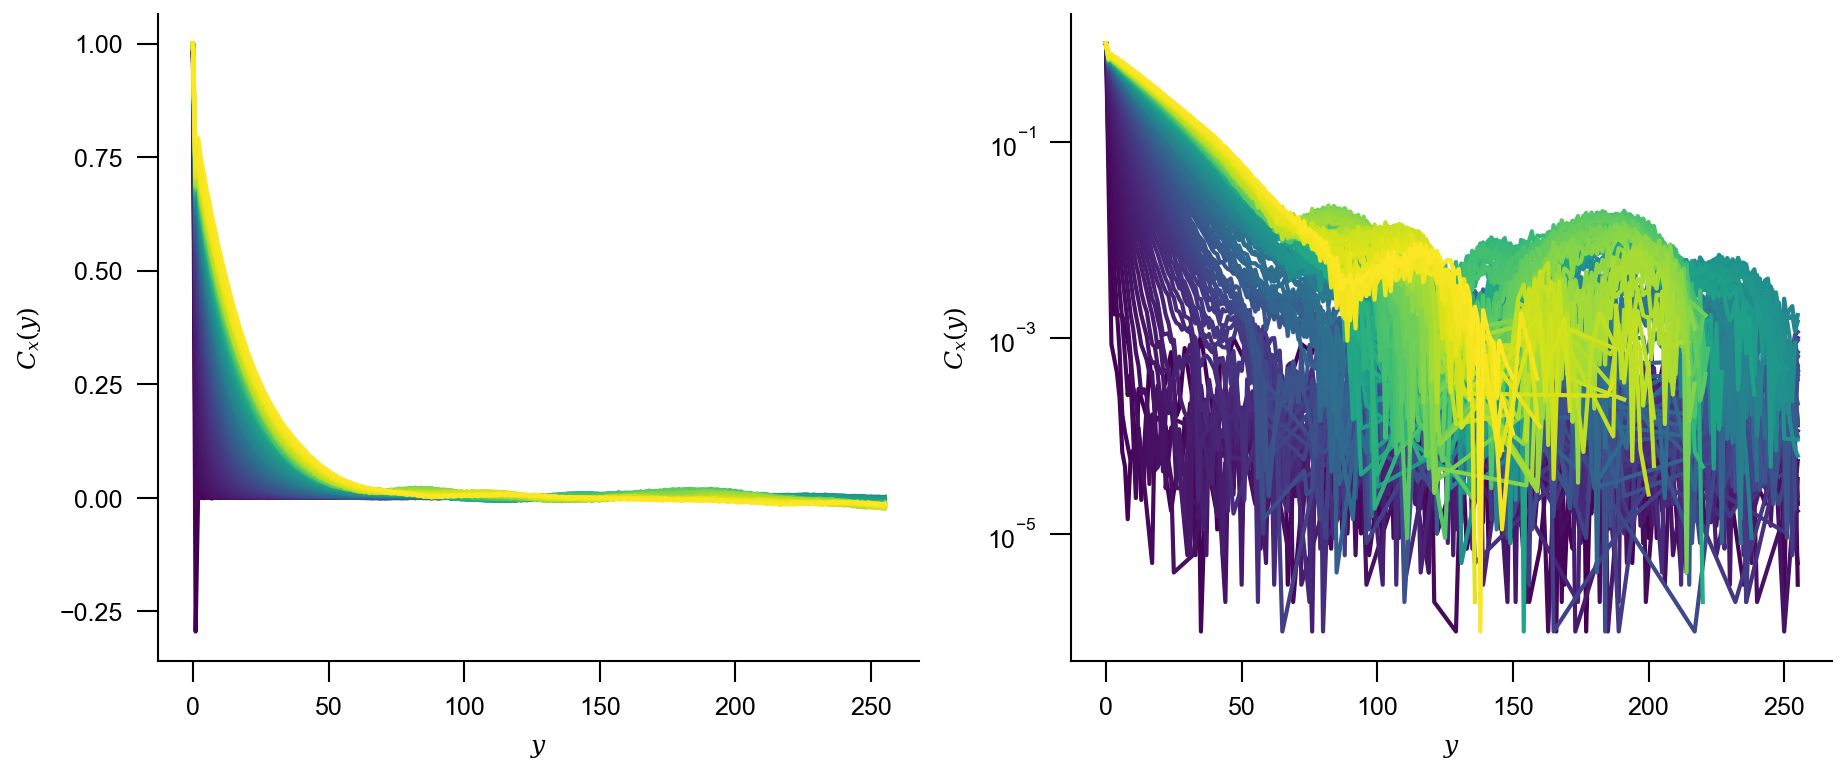

In [27]:
NCURVES = len(data)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    for i, line in enumerate(data):
        ax1.plot(np.arange(L2/2), line, c = colors[i])
        ax2.plot(np.arange(L2/2)[line >0], line[line >0], c = colors[i])
    
    ax1.set_xlabel(r'$y$')
    ax1.set_ylabel(r'$C_x (y)$')
    ax2.set_xlabel(r'$y$')
    ax2.set_ylabel(r'$C_x(y)$')
    ax2.set_yscale('log')
    fig.savefig('Corrfct.pdf', bbox_inches = 'tight', dpi = 300)
plt.show()

### Calcul longueur de correlation

/tmp/ipykernel_3730087/4086713682.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
/home/kduplat/Documents/Data/Pscript2/Fct_scripts/Toolbox/Fitting_fct.py:4: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)


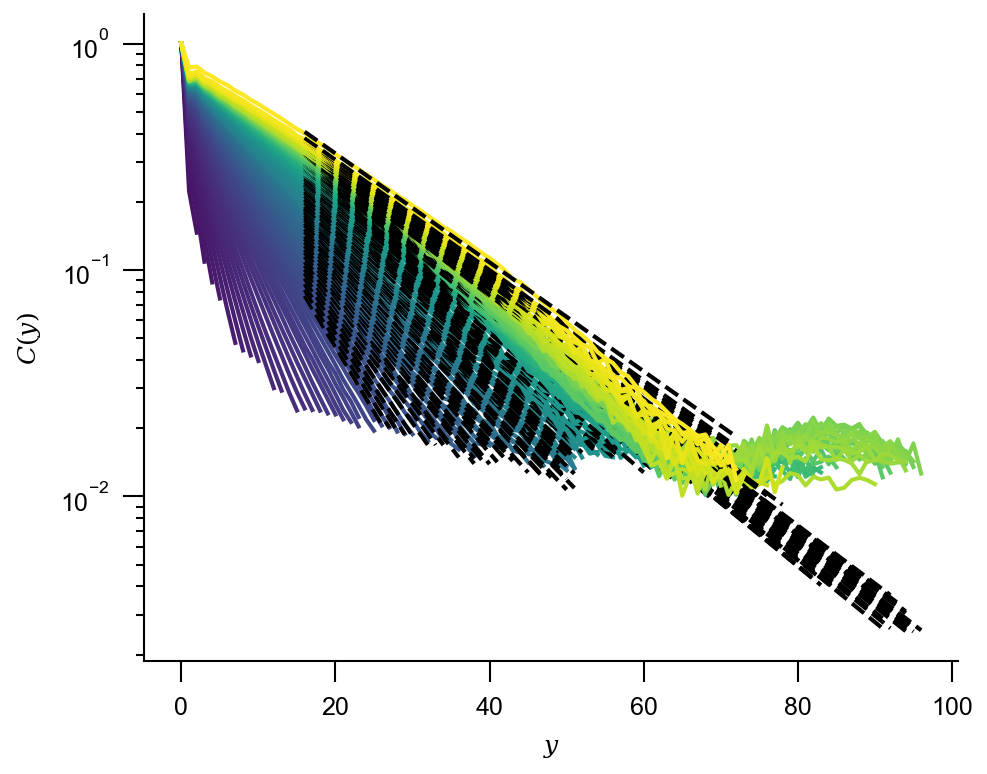

In [28]:

corrlen = np.zeros(len(data))
corrlen_fit = np.zeros_like(corrlen)

NCURVES = len(data)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, ax1 = plt.subplots(1,1,figsize = (3.5, 2.8))
    for i, line in enumerate(data):
        f_line = line
        f_y = np.arange(0, L2/2)
        
        ymax = 0
        if len(np.argwhere(f_line[5:] <1e-2) != 0) :
            ymax = np.argwhere(f_line[5:] <1e-2)[0][0] 
        else:
            ymax = 200
            
        f2_line = f_line[:ymax]
        f2_y = f_y[:ymax]
        ax1.plot(f2_y, f2_line, c = colors[i])
        
        corrlen[i] = np.sum(f2_line)
        if(len(f2_line[f2_y>15]) > 10):
            mask = (f2_y > 15) &  (f2_y < 200)
            f3_y = f2_y[mask]
            f3_line  =  f2_line[mask]
            
            
            popt, pcov = curve_fit(expfct, f3_y, f3_line)
            a, b = popt
            corrlen_fit[i] = 1/b
            xfit = f3_y
            y_fit = expfct(f3_y, a, b)
            ax1.plot(xfit, y_fit, c = 'k', ls = '--')

        
    ax1.set_xlabel(r'$y$')
    ax1.set_ylabel(r'$C(y)$')
    ax1.set_yscale('log')
plt.show()
    

### Correlation en fonction de la distance

128
128
17.188239


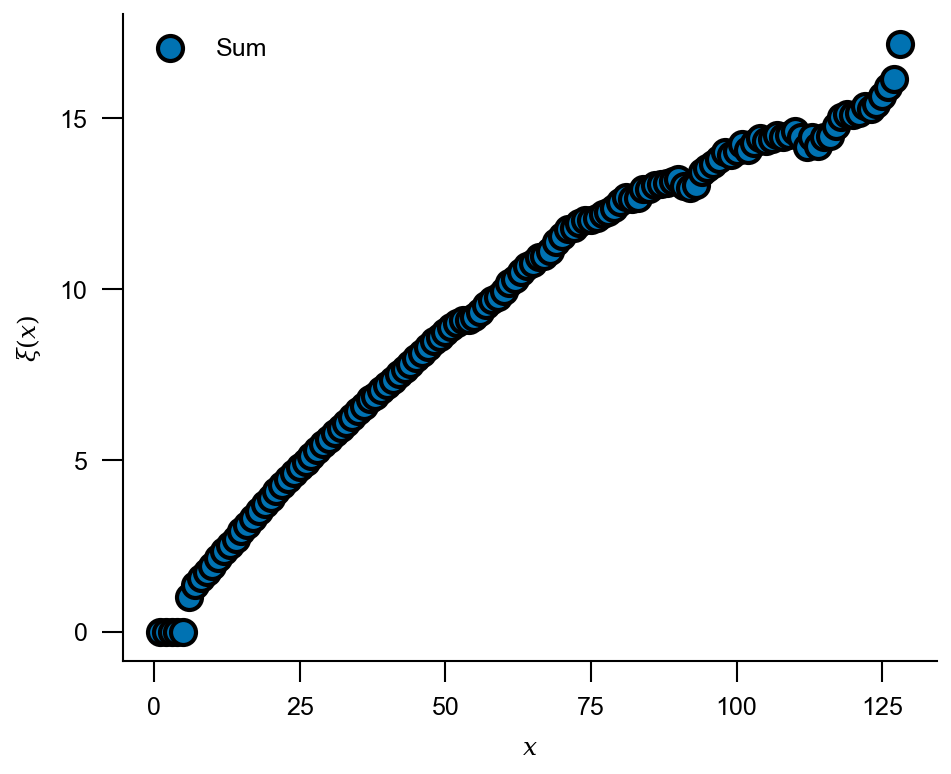

In [29]:
print(len(corrlen))
print(len(corrlen_fit))
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, ax1 = plt.subplots(1,figsize = (3.5, 2.8))

    ax1.scatter(np.arange(1, L1 +1), corrlen, label = 'Sum', c = color_list[0])
    print(corrlen[-1])
    # ax1.scatter(np.arange(1, L1 +1), corrlen_fit, label = 'Fit')
    
    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$\xi(x)$')
    # ax1.set_yscale('log')
    # ax1.set_xscale('log')
    ax1.legend()
    

plt.show()

## As function of the dissipation

/tmp/ipykernel_3730087/2290984472.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
/home/kduplat/Documents/Data/Pscript2/Fct_scripts/Toolbox/Fitting_fct.py:4: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)
/home/kduplat/Documents/Data/Pscript2/Fct_scripts/Toolbox/Fitting_fct.py:4: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-b * x)
/tmp/ipykernel_3730087/2290984472.py:46: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all poin

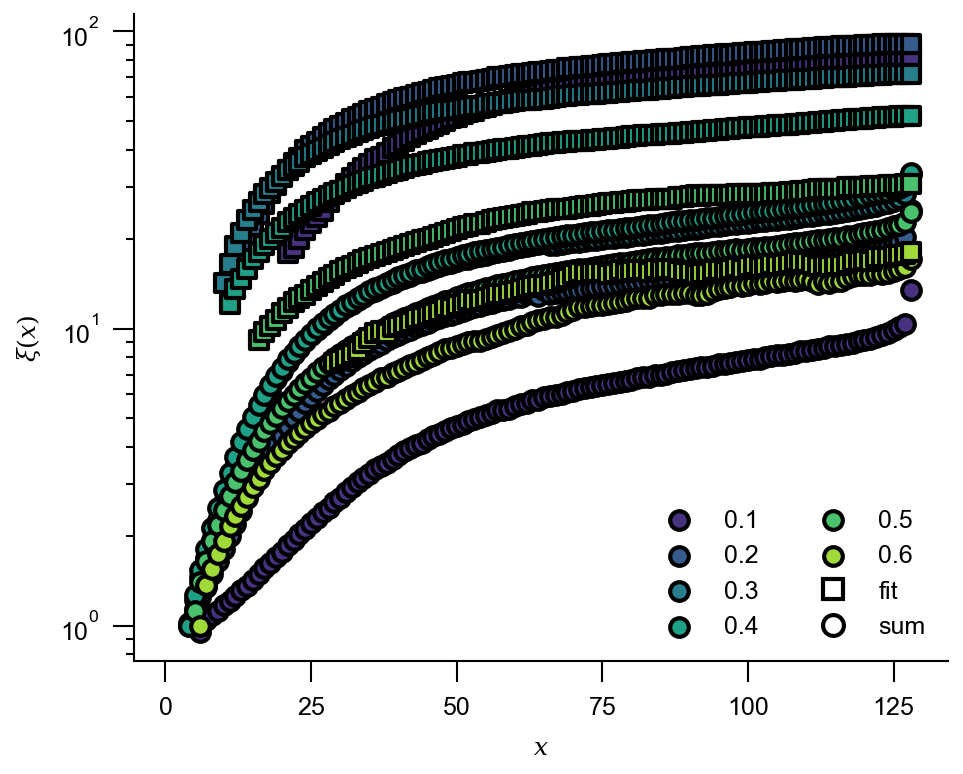

In [30]:

Tfolderpath = ["/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp3n{}".format(i) for i in range(1,8)]

NCURVES = len(Tfolderpath)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, ax1 = plt.subplots(1,1,figsize = (3.5, 2.8))
    for j, folder in enumerate(Tfolderpath):
        params = read_parameters(folder)
        L1 = params[0]
        L2 = params[1]
        nu = params[2]
        data = np.loadtxt("{}/tf_temp_outputB.txt".format(folder), comments = '#')
        
        corrlen = np.zeros(len(data))
        corrlen_fit = np.zeros_like(corrlen)

        for i, line in enumerate(data):
            f_line = line
            f_y = np.arange(0, L2/2)
            
            ymax = 0
            if len(np.argwhere(f_line[5:] <1e-2) != 0) :
                ymax = np.argwhere(f_line[5:] <1e-2)[0][0] 
            else:
                ymax = 200
            
            f2_line = f_line[:ymax]
            f2_y = f_y[:ymax]
            
            
            corrlen[i] = np.sum(f2_line)
            
            if(len(f2_line[f2_y>15]) > 10):
                mask = (f2_y > 15) &  (f2_y < 200)
                f3_y = f2_y[mask]
                f3_line  =  f2_line[mask]
                
                
                popt, pcov = curve_fit(expfct, f3_y, f3_line)
                a, b = popt
                corrlen_fit[i] = 1/b

        if nu != 0.0:
            ax1.scatter(np.arange(1, L1 +1), corrlen, label = nu, c = colors[j], s =20)
            ax1.scatter(np.arange(1, L1 +1), corrlen_fit, c = colors[j], marker = "s", s = 20)
        
    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$\xi(x)$')
    ax1.set_yscale('log')
    # ax1.set_xscale('log')
    # ax1.set_xlim(10,L2/2)
    
    square = Line2D([0], [0], marker='s', markerfacecolor='white',markersize=5, label='fit', c = 'w')
    circle = Line2D([0], [0], marker='o', markerfacecolor='white',markersize=5, label='sum', c = 'w')
    
    handles, labels = ax1.get_legend_handles_labels()
    handles.append(square)
    labels.append('fit')
    handles.append(circle)
    labels.append('sum')
    
    ax1.legend(handles=handles, labels=labels, ncol = 2)
    
    fig.savefig('Corrlen_x.pdf', bbox_inches = 'tight', dpi = 300)
plt.show()

## At the center of the system

/tmp/ipykernel_3730087/4100586288.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
/home/kduplat/Documents/Data/Pscript2/Fct_scripts/Toolbox/Fitting_fct.py:4: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)
/home/kduplat/Documents/Data/Pscript2/Fct_scripts/Toolbox/Fitting_fct.py:4: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-b * x)


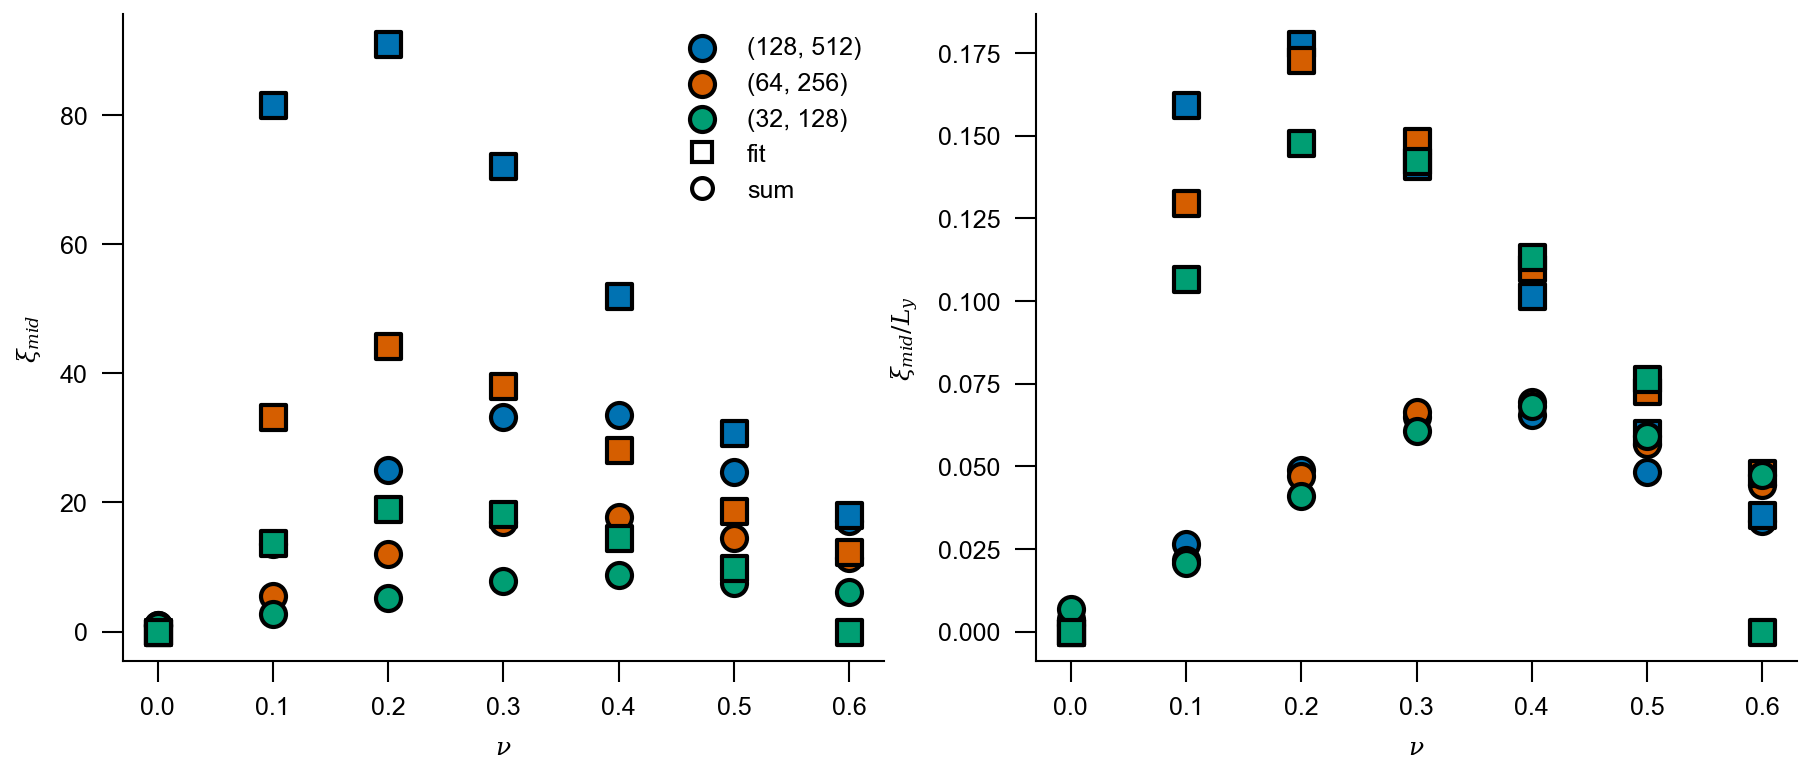

In [31]:
from matplotlib.lines import Line2D
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    
    for k, j in enumerate([3,6,9]):
        Tfolderpath = ["/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp{}n{}".format(j, i) for i in range(1,8)]

        NCURVES = len(Tfolderpath)
        colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

    
        for i, folder in enumerate(Tfolderpath):
            params = read_parameters(folder)
            nu = params[2]
            L2 = params[1]
            L1 = params[0]
            data = np.loadtxt("{}/tf_temp_outputB.txt".format(folder), comments = '#')
            line = data[-1]

            f_line = line
            f_y = np.arange(0, L2/2)
            
            ymax = 0
            if len(np.argwhere(f_line[5:] <1e-2) != 0) :
                ymax = np.argwhere(f_line[5:] <1e-2)[0][0] 
            else:
                ymax = 200
                
            f2_line = f_line[:ymax]
            f2_y = f_y[:ymax]
            
            corrlen_mid = np.sum(f2_line)
            
            
            if(len(f2_line[f2_y>15]) > 10):
                mask = (f2_y > 15) &  (f2_y < 200)
                f3_y = f2_y[mask]
                f3_line  =  f2_line[mask]
            
                popt, pcov = curve_fit(expfct, f3_y, f3_line)
                a, b = popt
                corrlen_fit = 1/b
            else: corrlen_fit =0
                
            corrlen_mid = np.sum(f2_line)
            # print(corrlen_mid)
            if i == 0:
                ax1.scatter(nu, corrlen_mid, c = color_list[k],  label = '({}, {})'.format(L1,L2))
            else:
                ax1.scatter(nu, corrlen_mid, c = color_list[k])
                
            ax1.scatter(nu, corrlen_fit, c = color_list[k], marker = 's')
            ax2.scatter(nu, corrlen_mid/L2, c = color_list[k])
            ax2.scatter(nu, corrlen_fit/L2, c = color_list[k], marker = 's')
            
    ax1.set_xlabel(r'$\nu$')
    ax1.set_ylabel(r'$\xi_{mid}$')
    ax2.set_xlabel(r'$\nu$')
    ax2.set_ylabel(r'$\xi_{mid}/L_y$')
    # ax1.set_yscale('log')
    # ax1.set_xscale('log')
    
    square = Line2D([0], [0], marker='s', markerfacecolor='white',markersize=5, label='fit', c = 'w')
    circle = Line2D([0], [0], marker='o', markerfacecolor='white',markersize=5, label='sum', c = 'w')
    
    
    
    handles, labels = ax1.get_legend_handles_labels()
    handles.append(square)
    labels.append('fit')
    handles.append(circle)
    labels.append('sum')
    
    ax1.legend(handles=handles, labels=labels)
    fig.savefig('Corrlen_nu.pdf', bbox_inches = 'tight', dpi = 300)
    plt.show()
        

#  Etude plus approfondie. Longueur de correlation en utilisant l'air sous la courbe PERbc

In [2]:
folder = "/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp10n7"
params = read_parameters(folder)
L1 = params[0]
L2 = params[1]

data = np.loadtxt("{}/tf_temp_outputB.txt".format(folder), comments = '#')
print(np.shape(data))
data = data[:int(len(data)/2), :]

(128, 256)


/tmp/ipykernel_1619505/3627243468.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


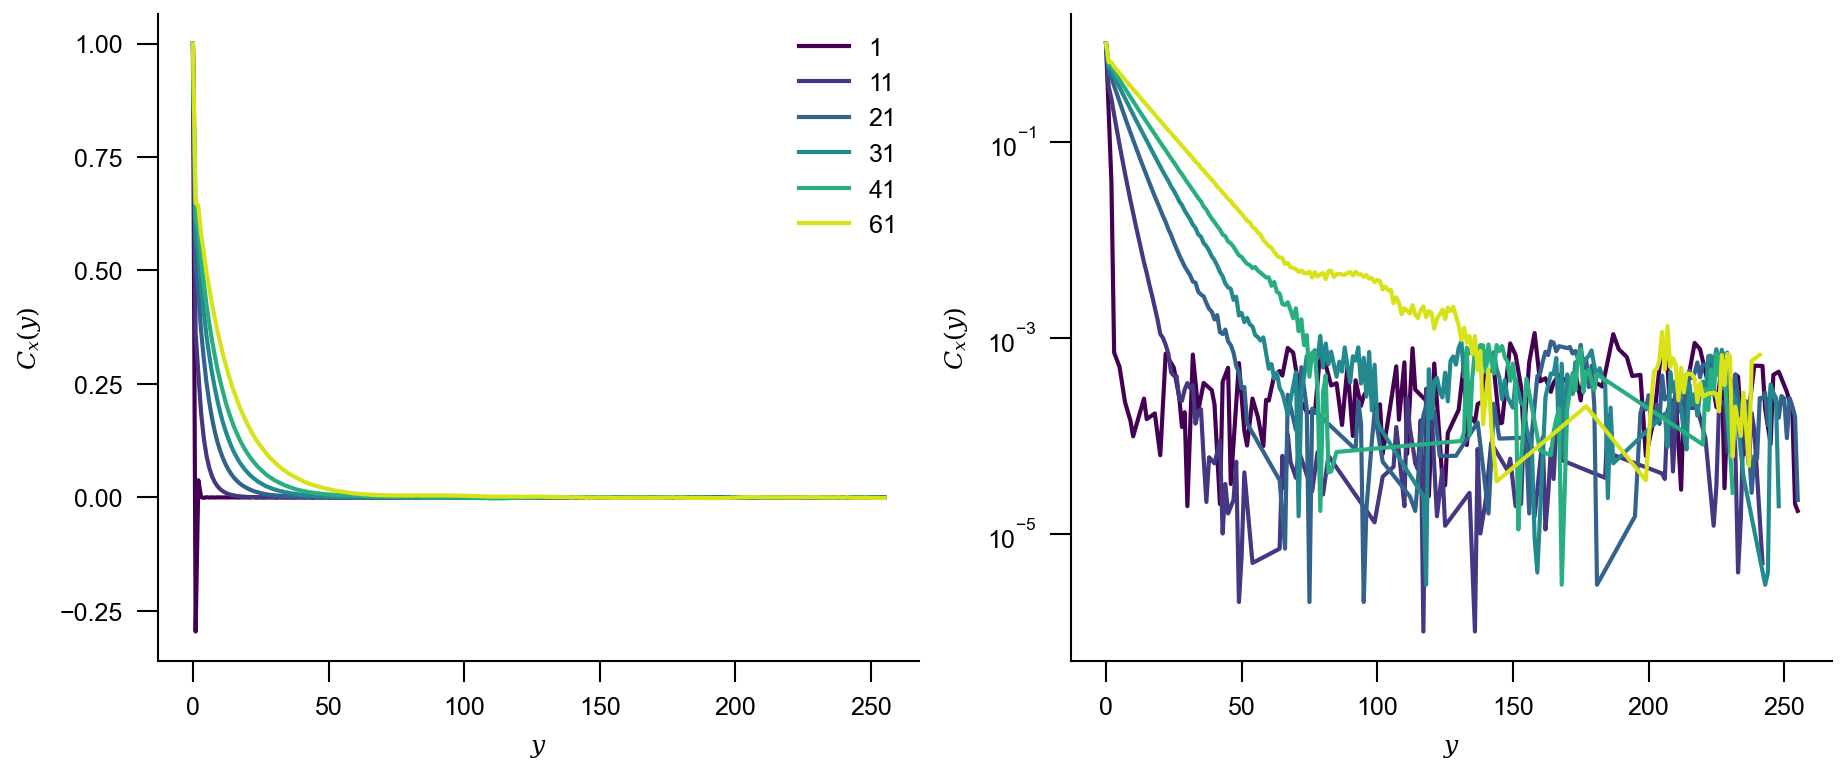

In [3]:
NCURVES = len(data)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

id_plot = [0,10,20,30,40,60]

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    for i, line in enumerate(data):
        if i in id_plot:
            ax1.plot(np.arange(L2/2), line, c = colors[i], label = i+1)
            ax2.plot(np.arange(L2/2)[line >0], line[line >0], c = colors[i])
    
    ax1.set_xlabel(r'$y$')
    ax1.set_ylabel(r'$C_x (y)$')
    ax2.set_xlabel(r'$y$')
    ax2.set_ylabel(r'$C_x(y)$')
    ax2.set_yscale('log')
    ax1.legend()
    fig.savefig('Corrfct.pdf', bbox_inches = 'tight', dpi = 300)
plt.show()

/tmp/ipykernel_1619505/4086713682.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
/home/kduplat/Documents/Data/Pscript2/Fct_scripts/Toolbox/Fitting_fct.py:4: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)


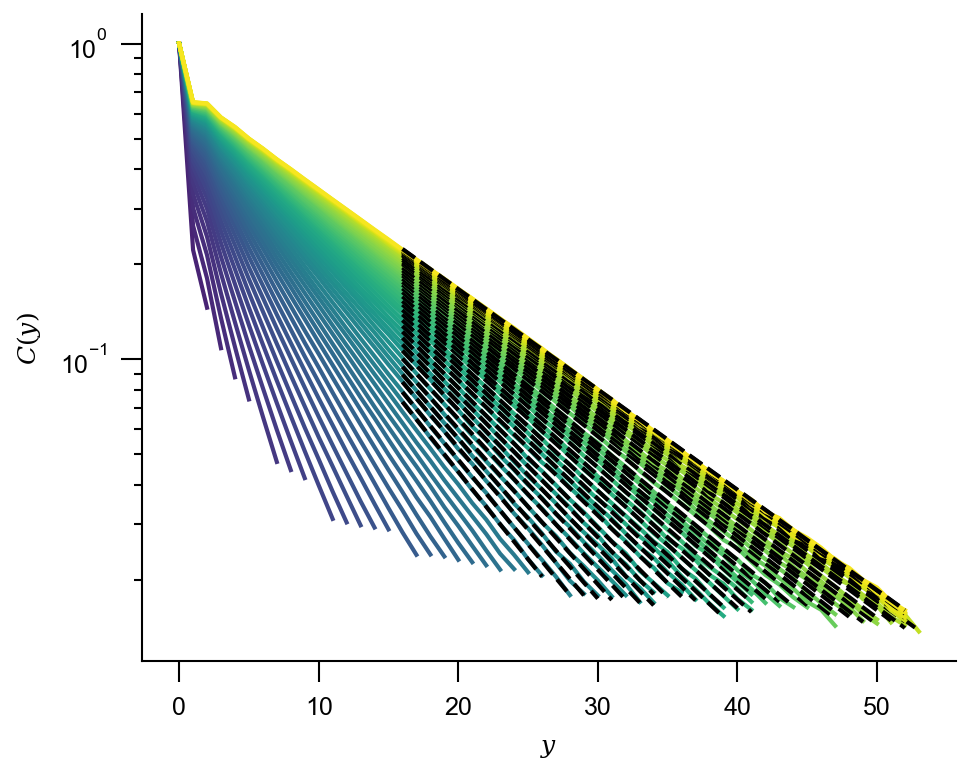

In [4]:

corrlen = np.zeros(len(data))
corrlen_fit = np.zeros_like(corrlen)

NCURVES = len(data)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, ax1 = plt.subplots(1,1,figsize = (3.5, 2.8))
    for i, line in enumerate(data):
        f_line = line
        f_y = np.arange(0, L2/2)
        
        ymax = 0
        if len(np.argwhere(f_line[5:] <1e-2) != 0) :
            ymax = np.argwhere(f_line[5:] <1e-2)[0][0] 
        else:
            ymax = 200
            
        f2_line = f_line[:ymax]
        f2_y = f_y[:ymax]
        ax1.plot(f2_y, f2_line, c = colors[i])
        
        corrlen[i] = np.sum(f2_line)
        if(len(f2_line[f2_y>15]) > 10):
            mask = (f2_y > 15) &  (f2_y < 200)
            f3_y = f2_y[mask]
            f3_line  =  f2_line[mask]
            
            
            popt, pcov = curve_fit(expfct, f3_y, f3_line)
            a, b = popt
            corrlen_fit[i] = 1/b
            xfit = f3_y
            y_fit = expfct(f3_y, a, b)
            ax1.plot(xfit, y_fit, c = 'k', ls = '--')

        
    ax1.set_xlabel(r'$y$')
    ax1.set_ylabel(r'$C(y)$')
    ax1.set_yscale('log')
plt.show()
    

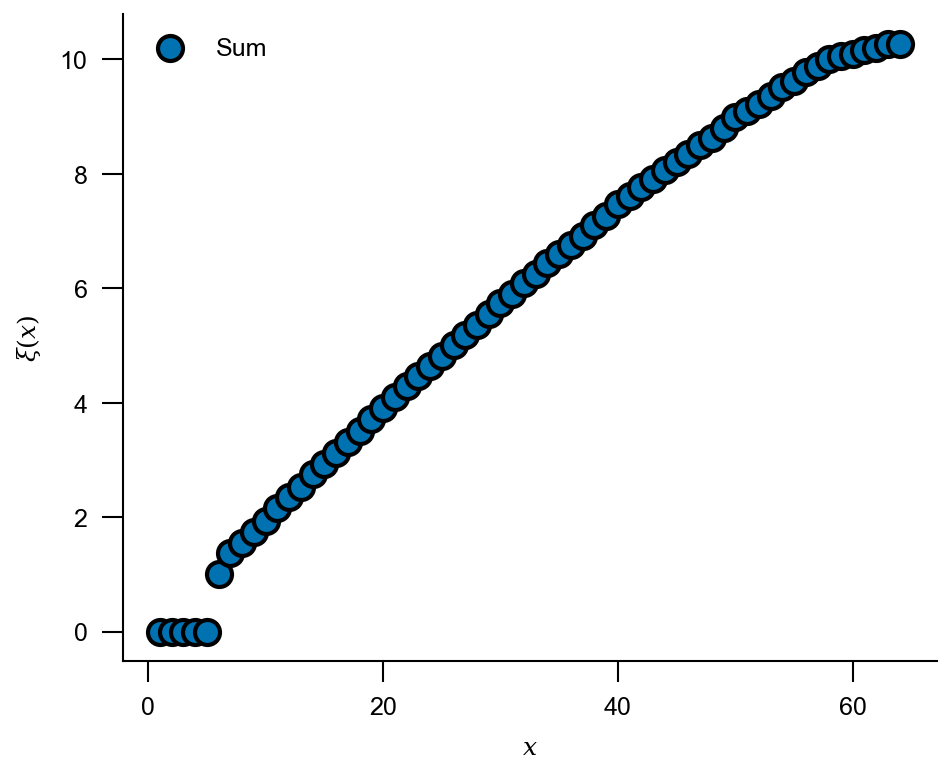

In [5]:

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, ax1 = plt.subplots(1,figsize = (3.5, 2.8))

    ax1.scatter(np.arange(1, L1/2 +1), corrlen, label = 'Sum', c = color_list[0])

    
    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$\xi(x)$')
    # ax1.set_yscale('log')
    # ax1.set_xscale('log')
    ax1.legend()
    

plt.show()

In [6]:
def corrlen_fit_and_sum(data, ymin = 1e-2, xmin = 15, xmax = 200, lenmin = 10):
    corrlen = np.zeros(len(data))
    corrlen_fit = np.zeros_like(corrlen)

    for i, line in enumerate(data):
        f_line = line
        f_y = np.arange(0, L2/2)
        
        ymax = 0
        if len(np.argwhere(f_line[5:] <ymin) != 0) :
            ymax = np.argwhere(f_line[5:] <ymin)[0][0] 
        else:
            ymax = xmax
        
        f2_line = f_line[:ymax]
        f2_y = f_y[:ymax]
        
        
        corrlen[i] = np.sum(f2_line)
        
        if(len(f2_line[f2_y>xmin]) > lenmin):
            mask = (f2_y > xmin) &  (f2_y < xmax)
            f3_y = f2_y[mask]
            f3_line  =  f2_line[mask]
            
            
            popt, pcov = curve_fit(expfct, f3_y, f3_line)
            a, b = popt
            corrlen_fit[i] = 1/b
    
    return corrlen, corrlen_fit

/tmp/ipykernel_1619505/2617750873.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
/home/kduplat/Documents/Data/Pscript2/Fct_scripts/Toolbox/Fitting_fct.py:4: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)
/tmp/ipykernel_1619505/2617750873.py:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(np.arange(1, L1/2 +1), corrlen, label = nu, c = colors[j], s =20)
/tmp/ipykernel_1619505/2617750873.py:22: UserWarning: *c* argument lo

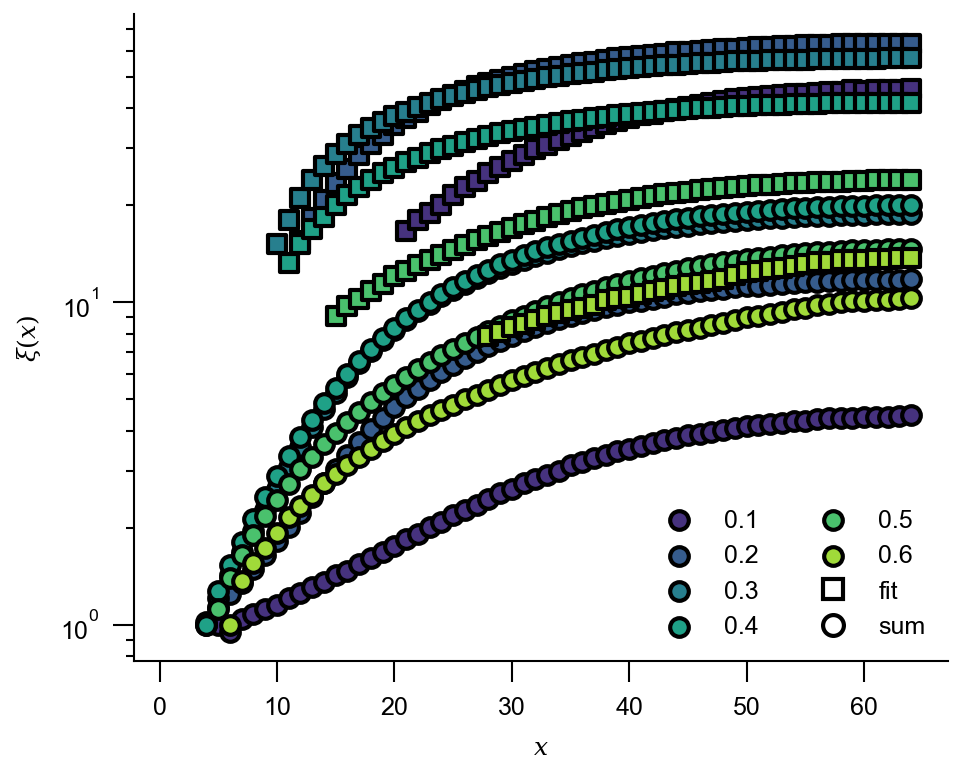

In [7]:

Tfolderpath = ["/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp10n{}".format(i) for i in range(1,8)]

NCURVES = len(Tfolderpath)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    
    fig, ax1 = plt.subplots(1,1,figsize = (3.5, 2.8))
    for j, folder in enumerate(Tfolderpath):
        params = read_parameters(folder)
        L1 = params[0]
        L2 = params[1]
        nu = params[2]
        data = np.loadtxt("{}/tf_temp_outputB.txt".format(folder), comments = '#')
        data = data[:int(len(data)/2), :]
        
        corrlen, corrlen_fit = corrlen_fit_and_sum(data)

        if nu != 0.0:
            ax1.scatter(np.arange(1, L1/2 +1), corrlen, label = nu, c = colors[j], s =20)
            ax1.scatter(np.arange(1, L1/2 +1), corrlen_fit, c = colors[j], marker = "s", s = 20)
        
    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$\xi(x)$')
    ax1.set_yscale('log')
    # ax1.set_xscale('log')
    # ax1.set_xlim(10,L2/2)
    
    square = Line2D([0], [0], marker='s', markerfacecolor='white',markersize=5, label='fit', c = 'w')
    circle = Line2D([0], [0], marker='o', markerfacecolor='white',markersize=5, label='sum', c = 'w')
    
    handles, labels = ax1.get_legend_handles_labels()
    handles.append(square)
    labels.append('fit')
    handles.append(circle)
    labels.append('sum')
    
    ax1.legend(handles=handles, labels=labels, ncol = 2)
    
    fig.savefig('Corrlen_x.pdf', bbox_inches = 'tight', dpi = 300)
    plt.show()

    
    

/tmp/ipykernel_1619505/2810524073.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
/tmp/ipykernel_1619505/2810524073.py:27: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(np.arange(1, L1/2 +1), corrlen, label = nu, c = colors[j], s =20)
/tmp/ipykernel_1619505/2810524073.py:33: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & 

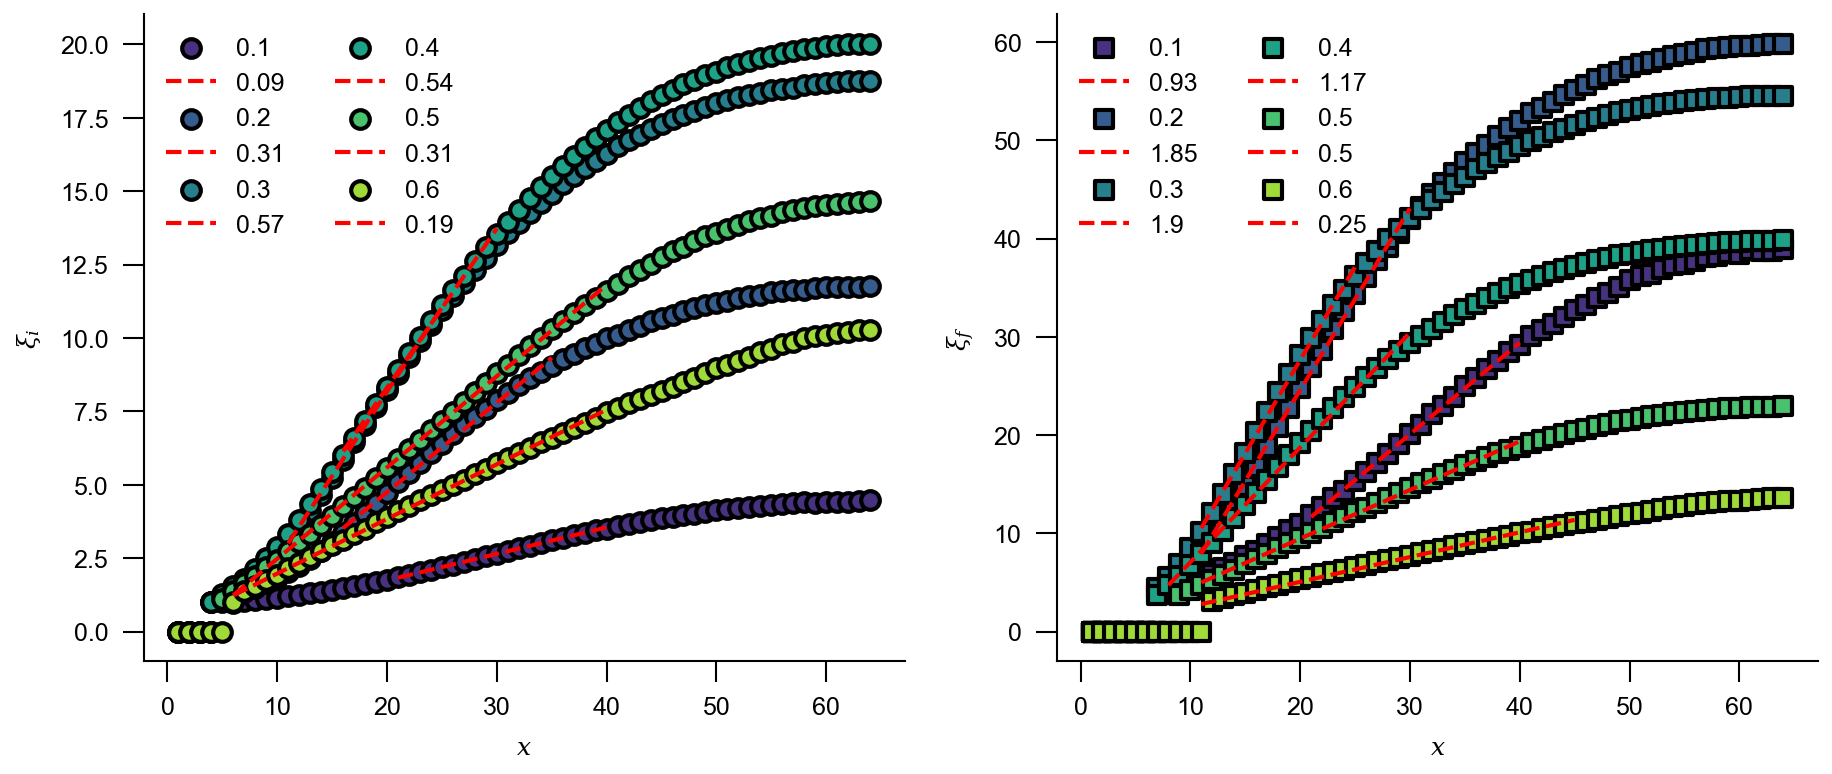

In [8]:

Tfolderpath = ["/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp10n{}".format(i) for i in range(1,8)]

NCURVES = len(Tfolderpath)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

xminsum = [20,15, 10, 15, 5,5]
xmaxsum = [40,35, 25, 30, 40,40]

xminfit = [20,10, 10, 7, 10,10]
xmaxfit = [40,30, 25, 30, 40,45]

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    for j, folder in enumerate(Tfolderpath):
        params = read_parameters(folder)
        L1 = params[0]
        L2 = params[1]
        nu = params[2]
        data = np.loadtxt("{}/tf_temp_outputB.txt".format(folder), comments = '#')
        data = data[:int(len(data)/2), :]
        
        corrlen, corrlen_fit = corrlen_fit_and_sum(data, xmin = 2, lenmin=5)

        if nu != 0.0:
            ax1.scatter(np.arange(1, L1/2 +1), corrlen, label = nu, c = colors[j], s =20)
            xfit_sum = np.arange(xminsum[j-1], xmaxsum[j-1] )
            popt, _ = curve_fit(linlaw, xfit_sum,corrlen[xminsum[j-1]:xmaxsum[j-1]])
            yfit_sum = linlaw(xfit_sum, *popt)
            ax1.plot(xfit_sum+1, yfit_sum, label = np.round(popt[0],2), c = 'r', ls = '--')
    
            ax2.scatter(np.arange(1, L1/2 +1), corrlen_fit, label = nu, c = colors[j], marker = "s", s = 20)
            xfit_fit = np.arange(xminfit[j-1], xmaxfit[j-1] )
            popt, _ = curve_fit(linlaw, xfit_fit,corrlen_fit[xminfit[j-1]:xmaxfit[j-1]])
            yfit_fit = linlaw(xfit_fit, *popt)
            ax2.plot(xfit_fit+1, yfit_fit, label = np.round(popt[0],2), c = 'r', ls = '--')
        
    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$\xi _i$')
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$\xi _f$')
    # ax1.set_yscale('log')
    # ax1.set_xscale('log')
    # ax2.set_yscale('log')
    # ax2.set_xscale('log')
    # ax1.set_xlim(10,L2/2)
    
    square = Line2D([0], [0], marker='s', markerfacecolor='white',markersize=5, label=r'$\xi _f$', c = 'w')
    circle = Line2D([0], [0], marker='o', markerfacecolor='white',markersize=5, label=r'$\xi _i$', c = 'w')
    
    handles, labels = ax1.get_legend_handles_labels()
    handles.append(square)
    labels.append(r'$\xi _f$')
    handles.append(circle)
    labels.append(r'$\xi _i$')
    
    # ax1.legend(handles=handles, labels=labels, ncol = 2)
    ax1.legend(ncol = 2)
    ax2.legend(ncol = 2)
    fig.savefig('Corrlen_x2.pdf', bbox_inches = 'tight', dpi = 300)
    plt.show()

    
    

/tmp/ipykernel_1619505/3951280949.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
/tmp/ipykernel_1619505/3951280949.py:27: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(np.arange(1, L1/2 +1), corrlen, label = nu, c = colors[j], s =20)
/tmp/ipykernel_1619505/3951280949.py:34: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & 

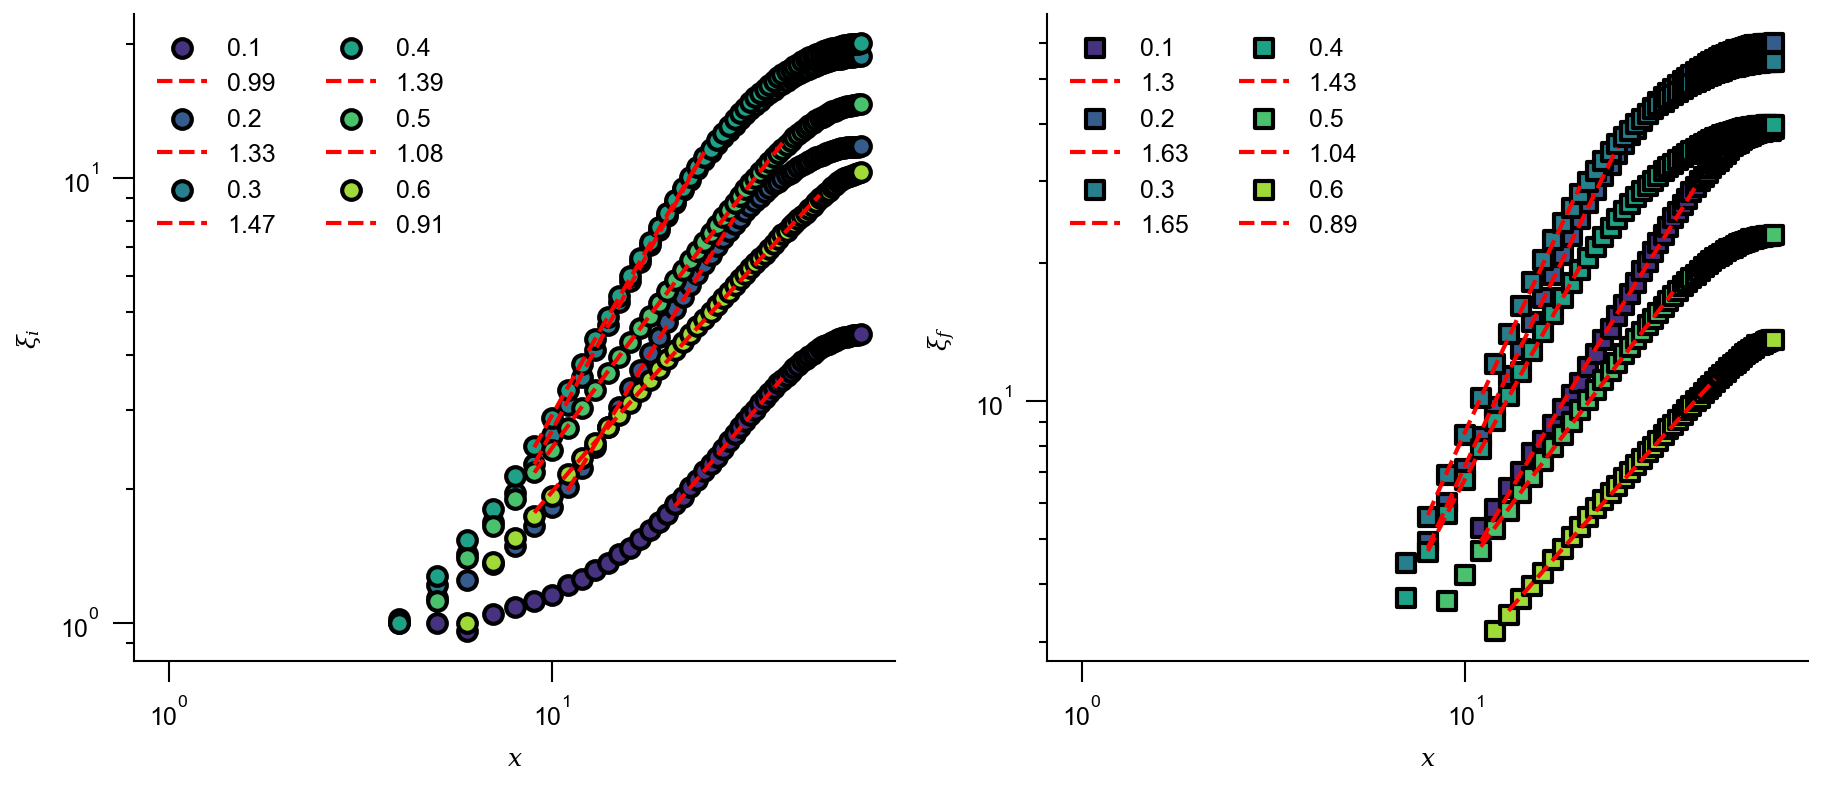

In [ ]:

Tfolderpath = ["/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp10n{}".format(i) for i in range(1,8)]

NCURVES = len(Tfolderpath)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

xminsum = [20,10, 8, 8, 8,8]
xmaxsum = [40,30, 25, 25, 40,50]

xminfit = [10,7, 7, 7, 10,12]
xmaxfit = [40,25, 20, 20, 35,45]

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    for j, folder in enumerate(Tfolderpath):
        params = read_parameters(folder)
        L1 = params[0]
        L2 = params[1]
        nu = params[2]
        data = np.loadtxt("{}/tf_temp_outputB.txt".format(folder), comments = '#')
        data = data[:int(len(data)/2), :]
        
        corrlen, corrlen_fit = corrlen_fit_and_sum(data, xmin = 2, lenmin=5)

        if nu != 0.0:
            ax1.scatter(np.arange(1, L1/2 +1), corrlen, label = nu, c = colors[j], s =20)
            xfit_sum = np.arange(xminsum[j-1], xmaxsum[j-1] )
            sigma = np.linspace(0.01, 1.0, len(xfit_sum))
            popt, _ = curve_fit(powerlaw2, np.log(xfit_sum),np.log(corrlen[xminsum[j-1]:xmaxsum[j-1]]), )
            yfit_sum = np.exp(powerlaw2(np.log(xfit_sum), *popt))
            ax1.plot(xfit_sum+1, yfit_sum, label = np.round(popt[1],2), c = 'r', ls = '--')
            
            ax2.scatter(np.arange(1, L1/2 +1), corrlen_fit, label = nu, c = colors[j], marker = "s", s = 20)
            xfit_fit = np.arange(xminfit[j-1], xmaxfit[j-1] )
            popt, _ = curve_fit(powerlaw2, np.log(xfit_fit),np.log(corrlen_fit[xminfit[j-1]:xmaxfit[j-1]]))
            yfit_fit = np.exp(powerlaw2(np.log(xfit_fit), *popt))
            ax2.plot(xfit_fit+1, yfit_fit, label = np.round(popt[1],2), c = 'r', ls = '--')
        
    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$\xi _i$')
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$\xi _f$')
    ax1.set_yscale('log')
    ax1.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xscale('log')
    # ax1.set_xlim(10,L2/2)
    
    square = Line2D([0], [0], marker='s', markerfacecolor='white',markersize=5, label=r'$\xi _f$', c = 'w')
    circle = Line2D([0], [0], marker='o', markerfacecolor='white',markersize=5, label=r'$\xi _i$', c = 'w')
    
    handles, labels = ax1.get_legend_handles_labels()
    handles.append(square)
    labels.append(r'$\xi _f$')
    handles.append(circle)
    labels.append(r'$\xi _i$')
    
    # ax1.legend(handles=handles, labels=labels, ncol = 2)
    ax1.legend(ncol = 2)
    ax2.legend(ncol = 2)
    
    fig.savefig('Corrlen_x2_loglog.pdf', bbox_inches = 'tight', dpi = 300)
    plt.show()

    
    

/tmp/ipykernel_1619505/1576943307.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
/home/kduplat/Documents/Data/Pscript2/Fct_scripts/Toolbox/Fitting_fct.py:4: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)
/home/kduplat/Documents/Data/Pscript2/Fct_scripts/Toolbox/Fitting_fct.py:4: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-b * x)
/home/kduplat/Documents/Data/Pscript2/Fct_scripts/Toolbox/Fitting_fct.py:24: RuntimeWarning: divide by zero encountered in power
  return A * x**n * np.exp(-x / B)


[6.57304308 1.39837412 0.12733604]
[8.41186085 1.61399738 0.12819476]


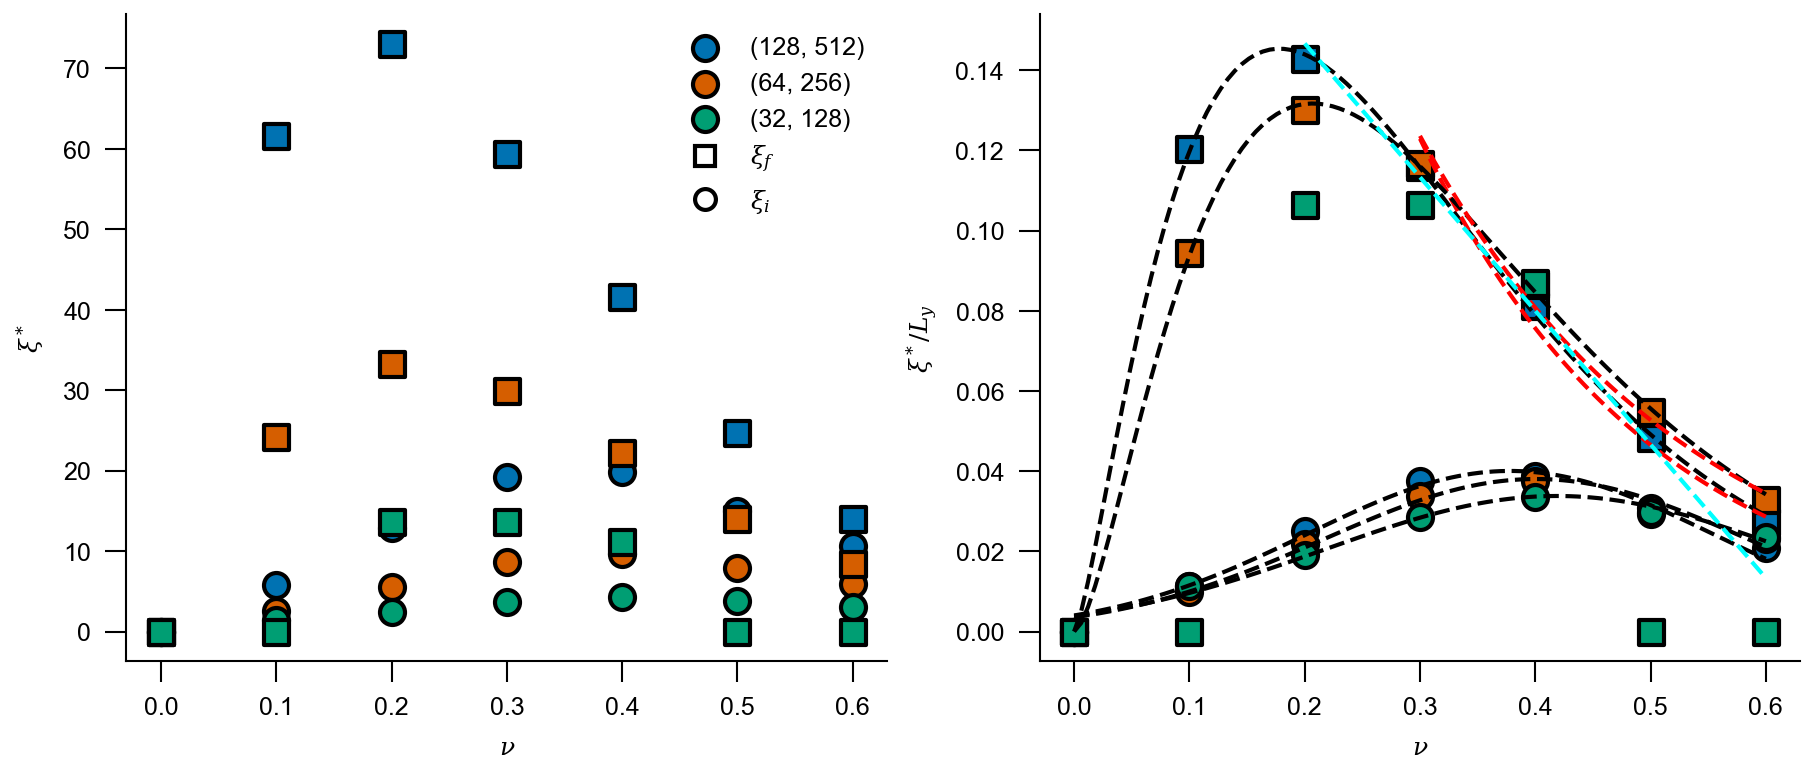

In [32]:
from matplotlib.lines import Line2D
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2,figsize = (7.2, 2.8))
    
    for k, j in enumerate([3,6,9]):
        Tfolderpath = ["/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp{}n{}".format(j, i) for i in range(1,8)]
        corrlen_mid = np.zeros(len(Tfolderpath))
        corrlen_fit_mid=np.zeros(len(Tfolderpath))
        NCURVES = len(Tfolderpath)
        colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
        Tnu = [read_parameters(folder)[2]for folder in Tfolderpath]
        
        for i, folder in enumerate(Tfolderpath):
            params = read_parameters(folder)
            nu = params[2]
            L2 = params[1]
            L1 = params[0]
            data = np.loadtxt("{}/tf_temp_outputB.txt".format(folder), comments = '#')
            data = data[:int(len(data)/2), :]
            
            corrlen, corrlen_fit = corrlen_fit_and_sum(data)
            
            if len(np.argwhere(corrlen!=0)) >0:
                corrlen_mid[i] = corrlen[-1]
            else:
                corrlen_mid[i] = 0
            if len(np.argwhere(corrlen_fit!=0)) >0:
                corrlen_fit_mid[i] = corrlen_fit[-1]
            else:
                corrlen_fit_mid[i] = 0 
                
                
            # corrlen_mid = np.sum(f2_line)
            if i == 0:
                ax1.scatter(nu, corrlen_mid[i], c = color_list[k],  label = '({}, {})'.format(L1,L2))
            else:
                ax1.scatter(nu, corrlen_mid[i], c = color_list[k])

            ax1.scatter(nu, corrlen_fit_mid[i], c = color_list[k], marker = 's')
            ax2.scatter(nu, corrlen_mid[i]/L2, c = color_list[k])
            ax2.scatter(nu, corrlen_fit_mid[i]/L2, c = color_list[k], marker = 's')
        
        popt1, pcov1 = curve_fit(gaussfct, Tnu, corrlen_mid/L2, maxfev = 1000)
        # xfit = np.array(Tnu)
        xfit = np.linspace(0,0.6,100)
        yfit1 = gaussfct(xfit, *popt1)
        ax2.plot(xfit, yfit1, ls = '--', c = 'k')
        
        
        
        if j !=9:
            popt2, pcov2 = curve_fit(gamma_distribution, Tnu, corrlen_fit_mid/L2, p0 =[10, 0.2, 0.1])
            yfit2 = gamma_distribution(xfit, *popt2)
            ax2.plot(xfit, yfit2, ls = '--', c = 'k')
            print (popt2)
            
            xfit = np.linspace(Tnu[3],Tnu[-1],100)
            popt2, pcov2 = curve_fit(expfct2, Tnu[3:], np.log(corrlen_fit_mid[3:]/L2), p0 =[ 0.2, 0.1])
            yfit2 = np.exp(expfct2(xfit, *popt2))
            ax2.plot(xfit, yfit2, ls = '--', c = 'r')
            
    ax2.plot(Tnu[2:], (1-np.array(Tnu[2:]))/3 - 0.12, c = 'cyan', ls = '--')
            
    ax1.set_xlabel(r'$\nu$')
    ax1.set_ylabel(r'$\xi^*$')
    ax2.set_xlabel(r'$\nu$')
    ax2.set_ylabel(r'$\xi^*/L_y$')
    # ax1.set_yscale('log')
    # ax1.set_xscale('log')
    # ax2.set_yscale('log')
    
    square = Line2D([0], [0], marker='s', markerfacecolor='white',markersize=5, label=r'$\xi _f$', c = 'w')
    circle = Line2D([0], [0], marker='o', markerfacecolor='white',markersize=5, label=r'$\xi _i$', c = 'w')
    
    handles, labels = ax1.get_legend_handles_labels()
    handles.append(square)
    labels.append(r'$\xi _f$')
    handles.append(circle)
    labels.append(r'$\xi _i$')
    
    ax1.legend(handles=handles, labels=labels)
    fig.savefig('Corrlen_nu.pdf', bbox_inches = 'tight', dpi = 300)
    plt.show()
        